# Daily Challenge: Understanding the Essence of Machine Learning
**Last Updated:** October 7th, 2025

---

##  **What You Will Learn**
- The fundamental concepts of Machine Learning (ML) and its importance in data analytics
- Different types of machine learning: Supervised, Unsupervised, and Reinforcement Learning
- The process of a machine learning model, including Feature Selection, Model Selection, and Model Evaluation

##  **What You Will Create**
- A comprehensive summary explaining the key aspects of Machine Learning
- Visual diagrams and flowcharts representing the ML process
- Practical code examples demonstrating different ML concepts

---

##  **Table of Contents**
1. [Import Required Libraries](#import)
2. [What is Machine Learning?](#basics)
3. [ML Applications Across Industries](#applications)
4. [Types of Machine Learning](#types)
5. [ML Process Visualization](#process)
6. [Feature Selection Techniques](#features)
7. [Model Selection Methods](#models)
8. [Model Evaluation Metrics](#evaluation)
9. [ML Process Flowchart](#flowchart)

---

## 1. Import Required Libraries {#import}

Let's start by importing all the necessary libraries for our Machine Learning exploration:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_blobs, load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print(" All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print("\n Ready to explore Machine Learning!")

 All libraries imported successfully!
NumPy version: 2.3.3
Pandas version: 2.3.3
Matplotlib version: 3.10.7
Seaborn version: 0.13.2

 Ready to explore Machine Learning!


## 2. What is Machine Learning? - Basic Concepts {#basics}

###  **Definition and Importance**

**Machine Learning (ML)** is a subset of artificial intelligence that enables computers to learn and make decisions from data without being explicitly programmed for each specific task. Instead of following pre-written instructions, ML algorithms identify patterns in data and use these patterns to make predictions or decisions on new, unseen data.

###  **Why is ML Important for Data Analysts?**

1. **Pattern Recognition**: ML can identify complex patterns that might be invisible to human analysis
2. **Scalability**: Handle massive datasets that would be impossible to analyze manually
3. **Predictive Power**: Make accurate predictions about future trends and behaviors
4. **Automation**: Automate repetitive analytical tasks, freeing analysts for strategic work
5. **Real-time Insights**: Process and analyze data in real-time for immediate decision-making

Let's create a simple visualization to understand how ML learns from data:

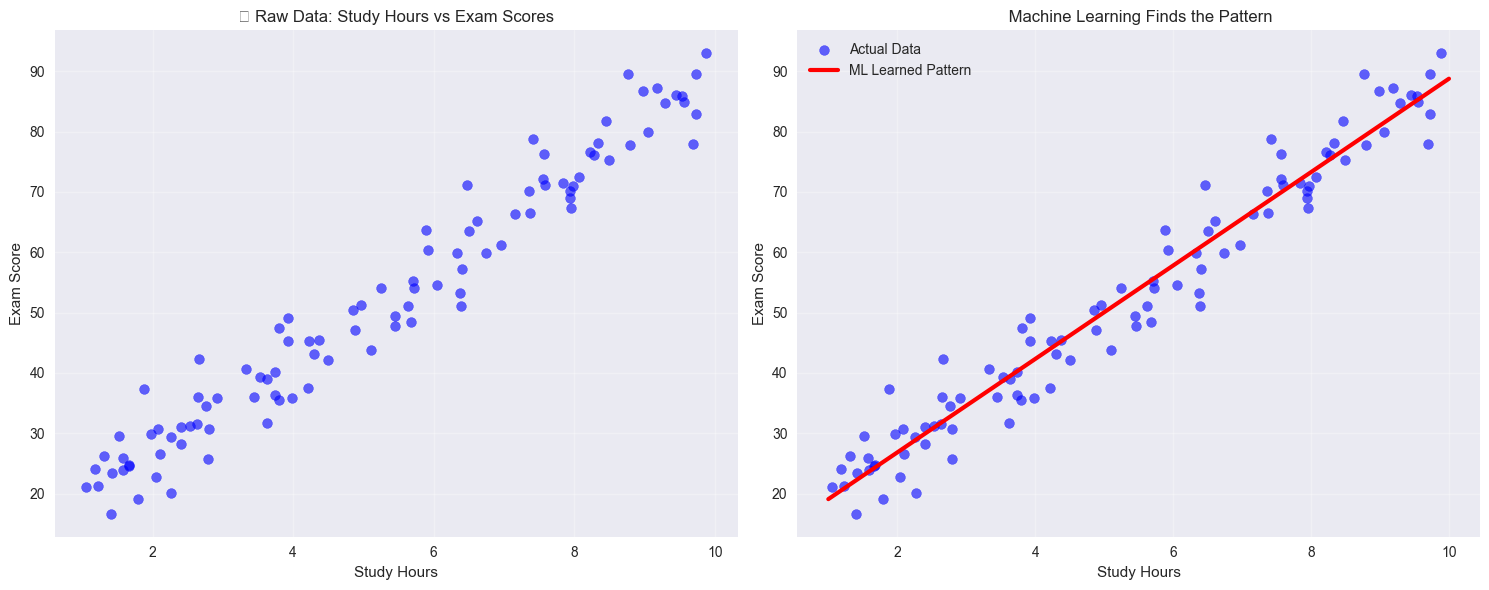

 What Machine Learning Discovered:
 For every additional hour of study, exam score increases by 7.74 points
 Base score (with 0 study hours): 11.33 points
 Model accuracy (R²): 0.955

 Prediction: If a student studies 7 hours, 
    expected exam score: 65.5 points


In [2]:

# sample data 
np.random.seed(42)
study_hours = np.random.uniform(1, 10, 100)
exam_scores = 10 + 8 * study_hours + np.random.normal(0, 5, 100)  # Linear relationship with noise

#  visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Raw data
ax1.scatter(study_hours, exam_scores, alpha=0.6, color='blue', s=50)
ax1.set_xlabel('Study Hours')
ax1.set_ylabel('Exam Score')
ax1.set_title('📚 Raw Data: Study Hours vs Exam Scores')
ax1.grid(True, alpha=0.3)

# Plot 2: ML learns the pattern
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(study_hours.reshape(-1, 1), exam_scores)

# Creating line for prediction
x_line = np.linspace(1, 10, 100)
y_line = model.predict(x_line.reshape(-1, 1))

ax2.scatter(study_hours, exam_scores, alpha=0.6, color='blue', s=50, label='Actual Data')
ax2.plot(x_line, y_line, color='red', linewidth=3, label='ML Learned Pattern')
ax2.set_xlabel('Study Hours')
ax2.set_ylabel('Exam Score')
ax2.set_title(' Machine Learning Finds the Pattern')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show the learned relationship
print(" What Machine Learning Discovered:")
print(f" For every additional hour of study, exam score increases by {model.coef_[0]:.2f} points")
print(f" Base score (with 0 study hours): {model.intercept_:.2f} points")
print(f" Model accuracy (R²): {model.score(study_hours.reshape(-1, 1), exam_scores):.3f}")

# Make a prediction
new_study_hours = 7
predicted_score = model.predict([[new_study_hours]])[0]
print(f"\n Prediction: If a student studies {new_study_hours} hours, ")
print(f"    expected exam score: {predicted_score:.1f} points")

## 3. Machine Learning Applications Across Industries {#applications}

Machine Learning is revolutionizing industries worldwide. Let's explore specific applications with visual examples:

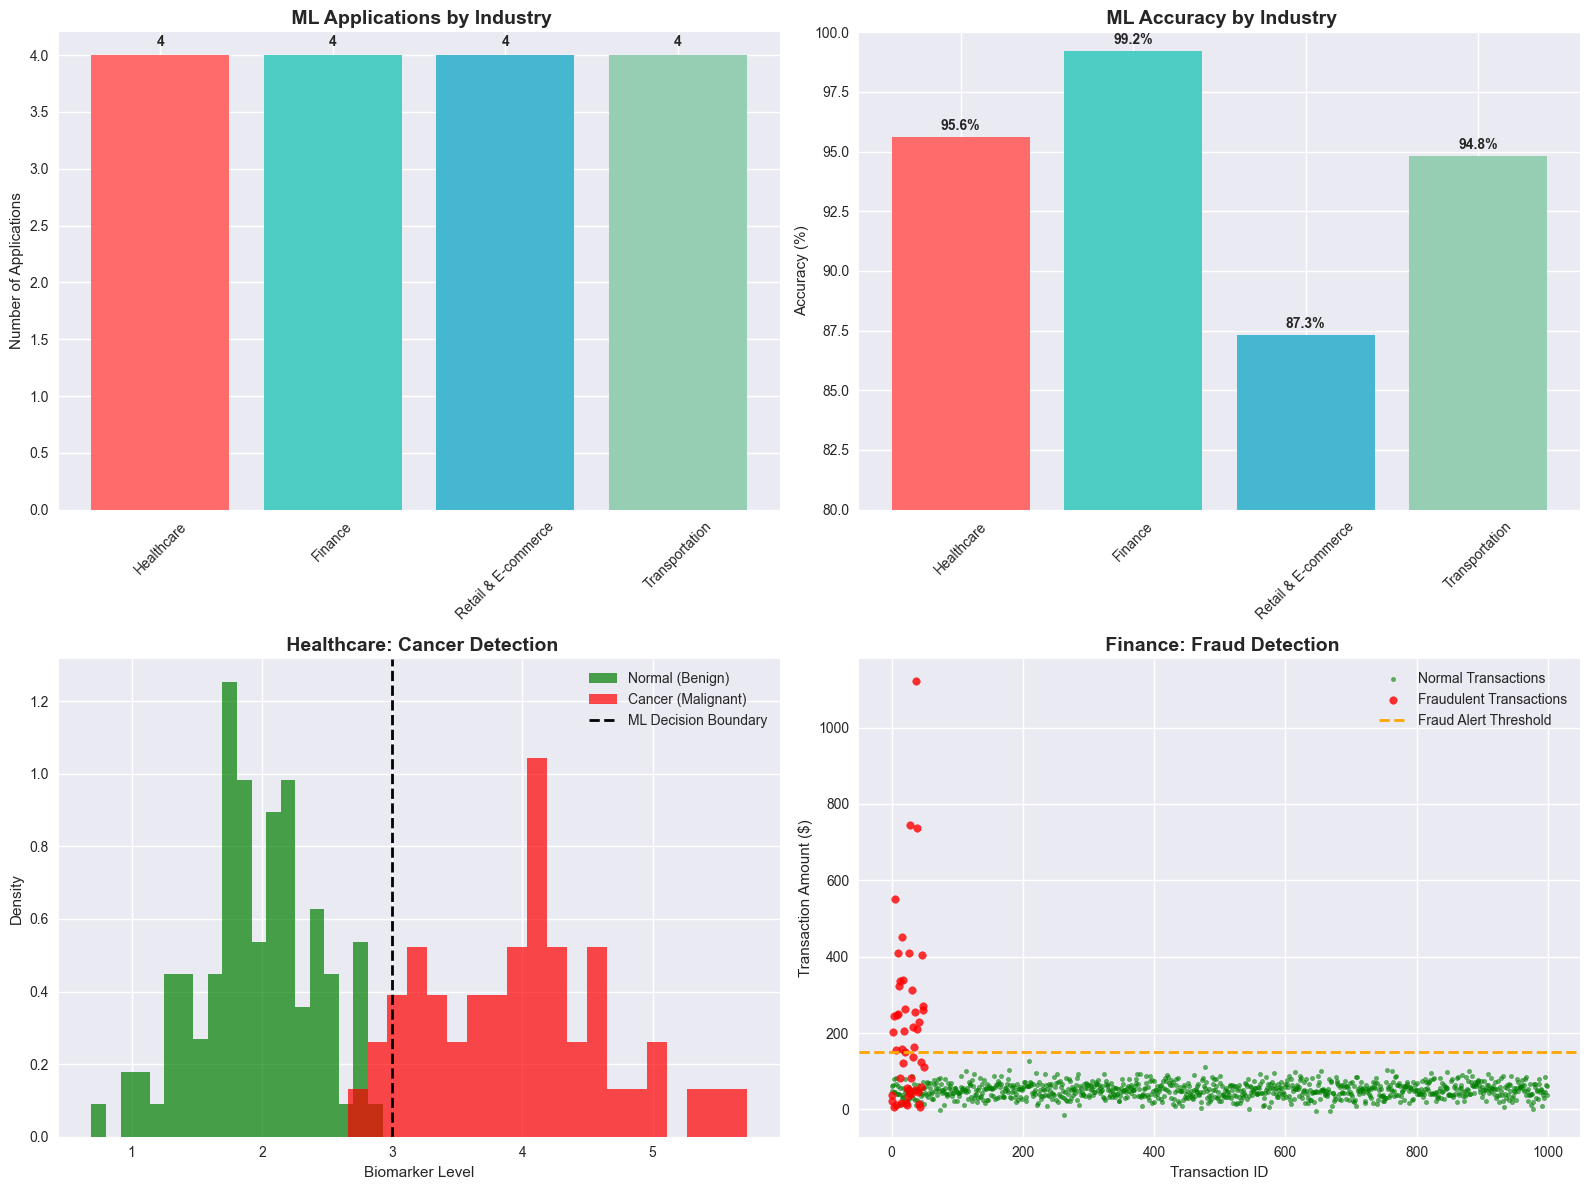

 DETAILED INDUSTRY APPLICATIONS

 HEALTHCARE
------------------------------
 Key Applications: Medical Diagnosis, Drug Discovery, Treatment Planning, Medical Imaging
 Example Use Case: Breast Cancer Detection
 Typical Accuracy: 95.6%
 Description: ML analyzes mammogram images to detect early signs of breast cancer with higher accuracy than traditional methods.
 Business Impact: Early detection saves lives by enabling timely treatment

 FINANCE
------------------------------
 Key Applications: Fraud Detection, Credit Scoring, Algorithmic Trading, Risk Assessment
 Example Use Case: Credit Card Fraud Detection
 Typical Accuracy: 99.2%
 Description: Real-time analysis of transaction patterns to identify suspicious activities and prevent fraudulent transactions.
 Business Impact: Prevents billions in financial losses annually

 RETAIL & E-COMMERCE
------------------------------
 Key Applications: Recommendation Systems, Price Optimization, Inventory Management, Customer Segmentation
 Exampl

In [3]:
industries = {
    'Healthcare': {
        'applications': ['Medical Diagnosis', 'Drug Discovery', 'Treatment Planning', 'Medical Imaging'],
        'example': 'Breast Cancer Detection',
        'accuracy': 95.6,
        'description': 'ML analyzes mammogram images to detect early signs of breast cancer with higher accuracy than traditional methods.',
        'impact': 'Early detection saves lives by enabling timely treatment'
    },
    'Finance': {
        'applications': ['Fraud Detection', 'Credit Scoring', 'Algorithmic Trading', 'Risk Assessment'],
        'example': 'Credit Card Fraud Detection',
        'accuracy': 99.2,
        'description': 'Real-time analysis of transaction patterns to identify suspicious activities and prevent fraudulent transactions.',
        'impact': 'Prevents billions in financial losses annually'
    },
    'Retail & E-commerce': {
        'applications': ['Recommendation Systems', 'Price Optimization', 'Inventory Management', 'Customer Segmentation'],
        'example': 'Product Recommendation Engine',
        'accuracy': 87.3,
        'description': 'Analyzes customer behavior and purchase history to suggest relevant products, increasing sales and customer satisfaction.',
        'impact': 'Increases revenue by 10-30% through personalized recommendations'
    },
    'Transportation': {
        'applications': ['Route Optimization', 'Autonomous Vehicles', 'Traffic Management', 'Predictive Maintenance'],
        'example': 'Autonomous Vehicle Navigation',
        'accuracy': 94.8,
        'description': 'Computer vision and sensor fusion enable vehicles to navigate safely without human intervention.',
        'impact': 'Reduces traffic accidents by up to 40%'
    }
}

#   visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Industry Applications Overview
industry_names = list(industries.keys())
app_counts = [len(industries[ind]['applications']) for ind in industry_names]

bars1 = ax1.bar(industry_names, app_counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax1.set_title(' ML Applications by Industry', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Applications')
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, count in zip(bars1, app_counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{count}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Accuracy Comparison
accuracies = [industries[ind]['accuracy'] for ind in industry_names]
bars2 = ax2.bar(industry_names, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax2.set_title(' ML Accuracy by Industry', fontsize=14, fontweight='bold')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(80, 100)
ax2.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, acc in zip(bars2, accuracies):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.2,
             f'{acc}%', ha='center', va='bottom', fontweight='bold')

# Plot 3: Healthcare Example - Simulated diagnostic data
np.random.seed(42)
normal_patients = np.random.normal(2, 0.5, 100)
cancer_patients = np.random.normal(4, 0.7, 50)

ax3.hist(normal_patients, bins=20, alpha=0.7, label='Normal (Benign)', color='green', density=True)
ax3.hist(cancer_patients, bins=20, alpha=0.7, label='Cancer (Malignant)', color='red', density=True)
ax3.axvline(x=3, color='black', linestyle='--', linewidth=2, label='ML Decision Boundary')
ax3.set_title(' Healthcare: Cancer Detection', fontsize=14, fontweight='bold')
ax3.set_xlabel('Biomarker Level')
ax3.set_ylabel('Density')
ax3.legend()

# Plot 4: Fraud Detection Example - Transaction patterns
np.random.seed(42)
normal_transactions = np.random.normal(50, 20, 1000)
fraud_transactions = np.random.exponential(200, 50)

ax4.scatter(range(len(normal_transactions)), normal_transactions, 
           alpha=0.6, s=10, color='green', label='Normal Transactions')
ax4.scatter(range(len(fraud_transactions)), fraud_transactions, 
           alpha=0.8, s=30, color='red', label='Fraudulent Transactions')
ax4.axhline(y=150, color='orange', linestyle='--', linewidth=2, label='Fraud Alert Threshold')
ax4.set_title(' Finance: Fraud Detection', fontsize=14, fontweight='bold')
ax4.set_xlabel('Transaction ID')
ax4.set_ylabel('Transaction Amount ($)')
ax4.legend()

plt.tight_layout()
plt.show()

# Print detailed information
print(" DETAILED INDUSTRY APPLICATIONS")
print("=" * 50)

for industry, data in industries.items():
    print(f"\n {industry.upper()}")
    print("-" * 30)
    print(f" Key Applications: {', '.join(data['applications'])}")
    print(f" Example Use Case: {data['example']}")
    print(f" Typical Accuracy: {data['accuracy']}%")
    print(f" Description: {data['description']}")
    print(f" Business Impact: {data['impact']}")

print(f"\n KEY INSIGHTS:")
print(f"✅ ML is transforming every major industry")
print(f"✅ Accuracy rates consistently exceed 85% across domains")
print(f"✅ Real-world impact includes saving lives, preventing fraud, and improving efficiency")
print(f"✅ Applications range from life-critical (healthcare) to business-critical (finance)")

## 4. Types of Machine Learning {#types}

There are three main paradigms of Machine Learning, each suited for different types of problems. Let's explore each with definitions, characteristics, and practical examples:

 1. SUPERVISED LEARNING
Definition: Learning from labeled training data to make predictions on new data
Key Characteristic: We know the correct answers during training
Example Scenario: Email spam detection - we have emails labeled as 'spam' or 'not spam'

 2. UNSUPERVISED LEARNING
Definition: Finding hidden patterns in data without labeled examples
Key Characteristic: No correct answers provided - algorithm finds structure
Example Scenario: Customer segmentation - grouping customers by behavior patterns

 3. REINFORCEMENT LEARNING
Definition: Learning through interaction with environment via rewards and penalties
Key Characteristic: Agent learns optimal actions through trial and error
Example Scenario: Game AI learning to play chess by playing many games


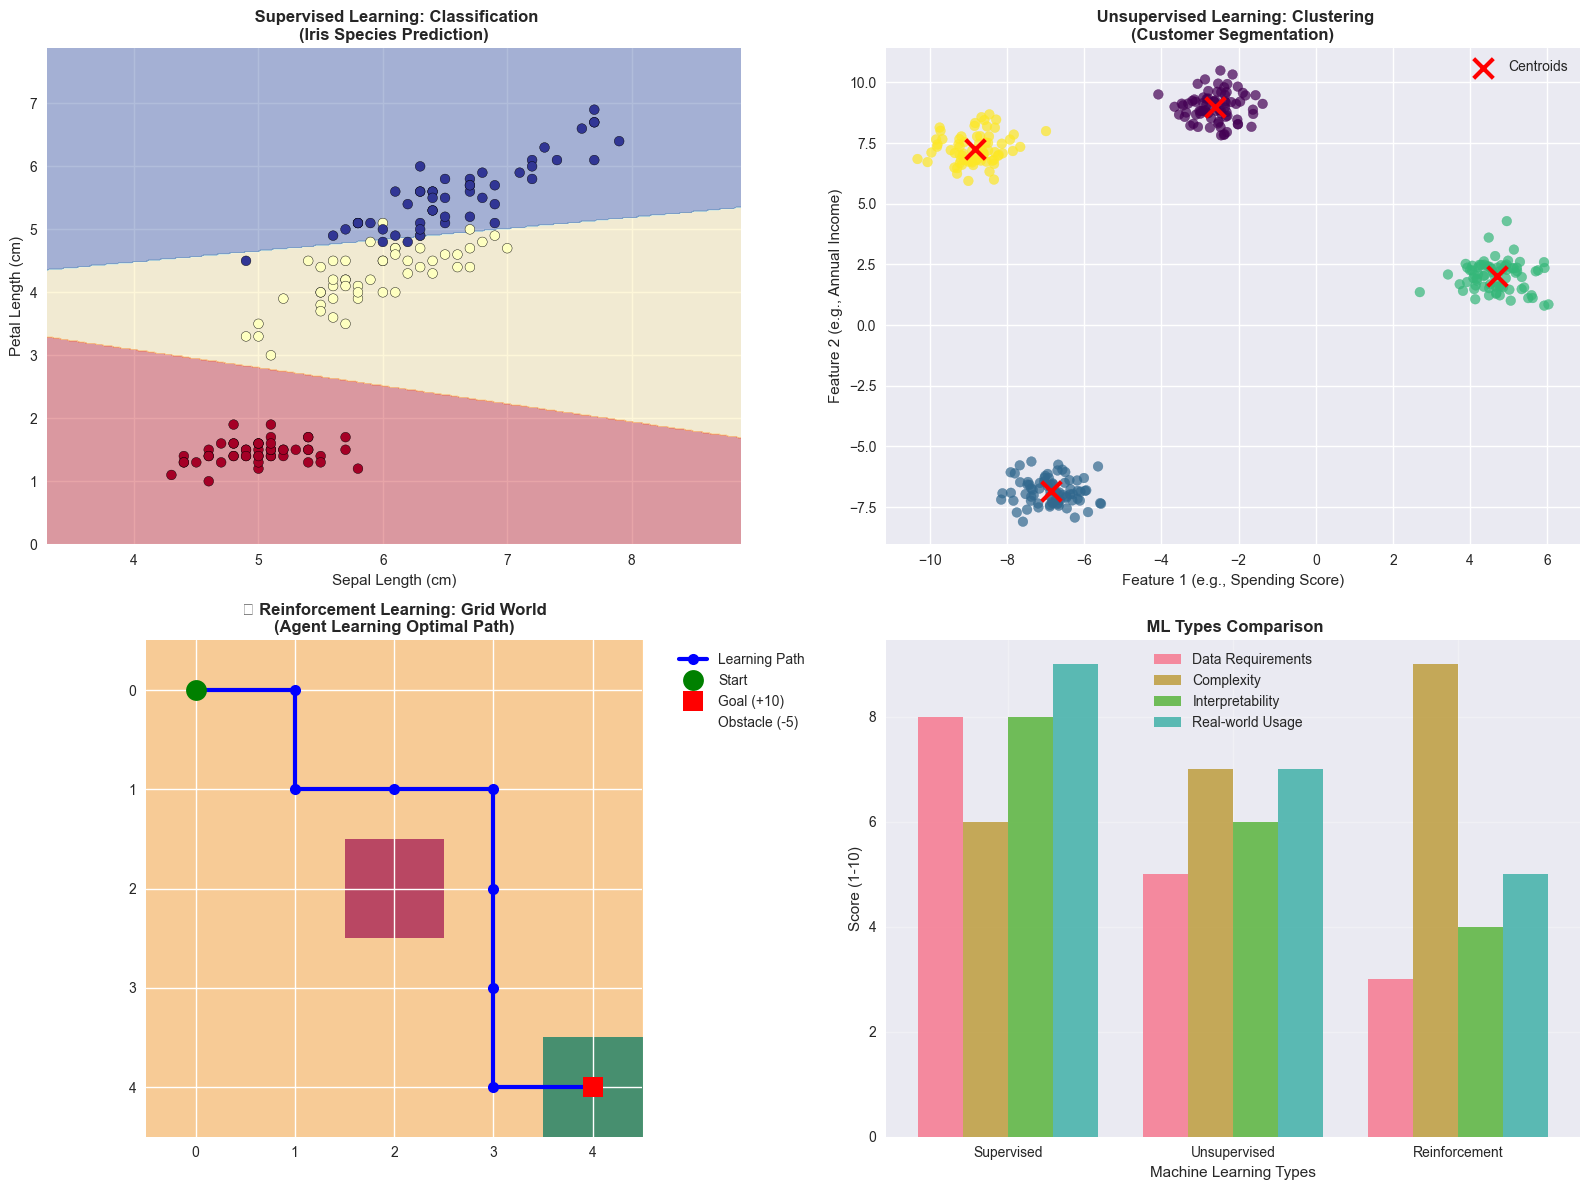


 DETAILED COMPARISON TABLE
         Aspect                   Supervised                         Unsupervised            Reinforcement
      Data Type Labeled (input-output pairs)               Unlabeled (input only) Environment interactions
Learning Method          Learn from examples                 Find hidden patterns          Trial and error
           Goal             Predict outcomes                   Discover structure         Maximize rewards
       Examples   Classification, Regression Clustering, Dimensionality Reduction        Game AI, Robotics
       Accuracy            High (measurable)                      Hard to measure       Improves over time
     Complexity                       Medium                          Medium-High                     High

 KEY TAKEAWAYS:
✅ Supervised Learning: Best when you have labeled data and want predictions
✅ Unsupervised Learning: Best for discovering hidden patterns in data
✅ Reinforcement Learning: Best for sequential decision-makin

In [4]:

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

print(" 1. SUPERVISED LEARNING")
print("=" * 40)
print("Definition: Learning from labeled training data to make predictions on new data")
print("Key Characteristic: We know the correct answers during training")
print("Example Scenario: Email spam detection - we have emails labeled as 'spam' or 'not spam'")


iris = load_iris()
X_iris = iris.data[:, [0, 2]]  
y_iris = iris.target

# Training a simple classifier
classifier = LogisticRegression()
classifier.fit(X_iris, y_iris)

# Creating decision boundary visualization
h = 0.02
x_min, x_max = X_iris[:, 0].min() - 1, X_iris[:, 0].max() + 1
y_min, y_max = X_iris[:, 1].min() - 1, X_iris[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

ax1.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
scatter = ax1.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, cmap=plt.cm.RdYlBu, edgecolors='black')
ax1.set_title(' Supervised Learning: Classification\n(Iris Species Prediction)', fontweight='bold')
ax1.set_xlabel('Sepal Length (cm)')
ax1.set_ylabel('Petal Length (cm)')

# 2. UNSUPERVISED LEARNING  - Clustering
print(f"\n 2. UNSUPERVISED LEARNING")
print("=" * 40)
print("Definition: Finding hidden patterns in data without labeled examples")
print("Key Characteristic: No correct answers provided - algorithm finds structure")
print("Example Scenario: Customer segmentation - grouping customers by behavior patterns")

# Generate clustering data
X_cluster, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# Applying K-means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

ax2.scatter(X_cluster[:, 0], X_cluster[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
ax2.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
           marker='x', s=200, linewidths=3, color='red', label='Centroids')
ax2.set_title(' Unsupervised Learning: Clustering\n(Customer Segmentation)', fontweight='bold')
ax2.set_xlabel('Feature 1 (e.g., Spending Score)')
ax2.set_ylabel('Feature 2 (e.g., Annual Income)')
ax2.legend()

# 3. REINFORCEMENT LEARNING SIMULATION
print(f"\n 3. REINFORCEMENT LEARNING")
print("=" * 40)
print("Definition: Learning through interaction with environment via rewards and penalties")
print("Key Characteristic: Agent learns optimal actions through trial and error")
print("Example Scenario: Game AI learning to play chess by playing many games")

# Simple grid world simulation
grid_size = 5
rewards = np.zeros((grid_size, grid_size))
rewards[4, 4] = 10  # Goal position
rewards[2, 2] = -5  # Obstacle

# Simulate learning path
learning_path = [(0, 0), (0, 1), (1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (4, 3), (4, 4)]

# Visualize the grid world
im = ax3.imshow(rewards, cmap='RdYlGn', alpha=0.7)
ax3.set_title('🎮 Reinforcement Learning: Grid World\n(Agent Learning Optimal Path)', fontweight='bold')

# Draw the learning path
path_x = [pos[1] for pos in learning_path]
path_y = [pos[0] for pos in learning_path]
ax3.plot(path_x, path_y, 'b-o', linewidth=3, markersize=8, label='Learning Path')
ax3.plot(0, 0, 'go', markersize=15, label='Start')
ax3.plot(4, 4, 'rs', markersize=15, label='Goal (+10)')
ax3.plot(2, 2, 'kx', markersize=15, label='Obstacle (-5)')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Comparison Chart
ml_types = ['Supervised', 'Unsupervised', 'Reinforcement']
characteristics = {
    'Data Requirements': [8, 5, 3],  # Relative scale
    'Complexity': [6, 7, 9],
    'Interpretability': [8, 6, 4],
    'Real-world Usage': [9, 7, 5]
}

x = np.arange(len(ml_types))
width = 0.2

for i, (char, values) in enumerate(characteristics.items()):
    ax4.bar(x + i*width, values, width, label=char, alpha=0.8)

ax4.set_title(' ML Types Comparison', fontweight='bold')
ax4.set_xlabel('Machine Learning Types')
ax4.set_ylabel('Score (1-10)')
ax4.set_xticks(x + width * 1.5)
ax4.set_xticklabels(ml_types)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#  comparison table
print(f"\n DETAILED COMPARISON TABLE")
print("=" * 60)

comparison_data = {
    'Aspect': ['Data Type', 'Learning Method', 'Goal', 'Examples', 'Accuracy', 'Complexity'],
    'Supervised': [
        'Labeled (input-output pairs)',
        'Learn from examples',
        'Predict outcomes',
        'Classification, Regression',
        'High (measurable)',
        'Medium'
    ],
    'Unsupervised': [
        'Unlabeled (input only)',
        'Find hidden patterns',
        'Discover structure',
        'Clustering, Dimensionality Reduction',
        'Hard to measure',
        'Medium-High'
    ],
    'Reinforcement': [
        'Environment interactions',
        'Trial and error',
        'Maximize rewards',
        'Game AI, Robotics',
        'Improves over time',
        'High'
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

print(f"\n KEY TAKEAWAYS:")
print(f"✅ Supervised Learning: Best when you have labeled data and want predictions")
print(f"✅ Unsupervised Learning: Best for discovering hidden patterns in data")
print(f"✅ Reinforcement Learning: Best for sequential decision-making problems")
print(f"✅ Choice depends on your data type and business objective")

## 5. Machine Learning Process Visualization {#process}

The Machine Learning process follows a systematic workflow from raw data to deployed model. Let's visualize this comprehensive process:

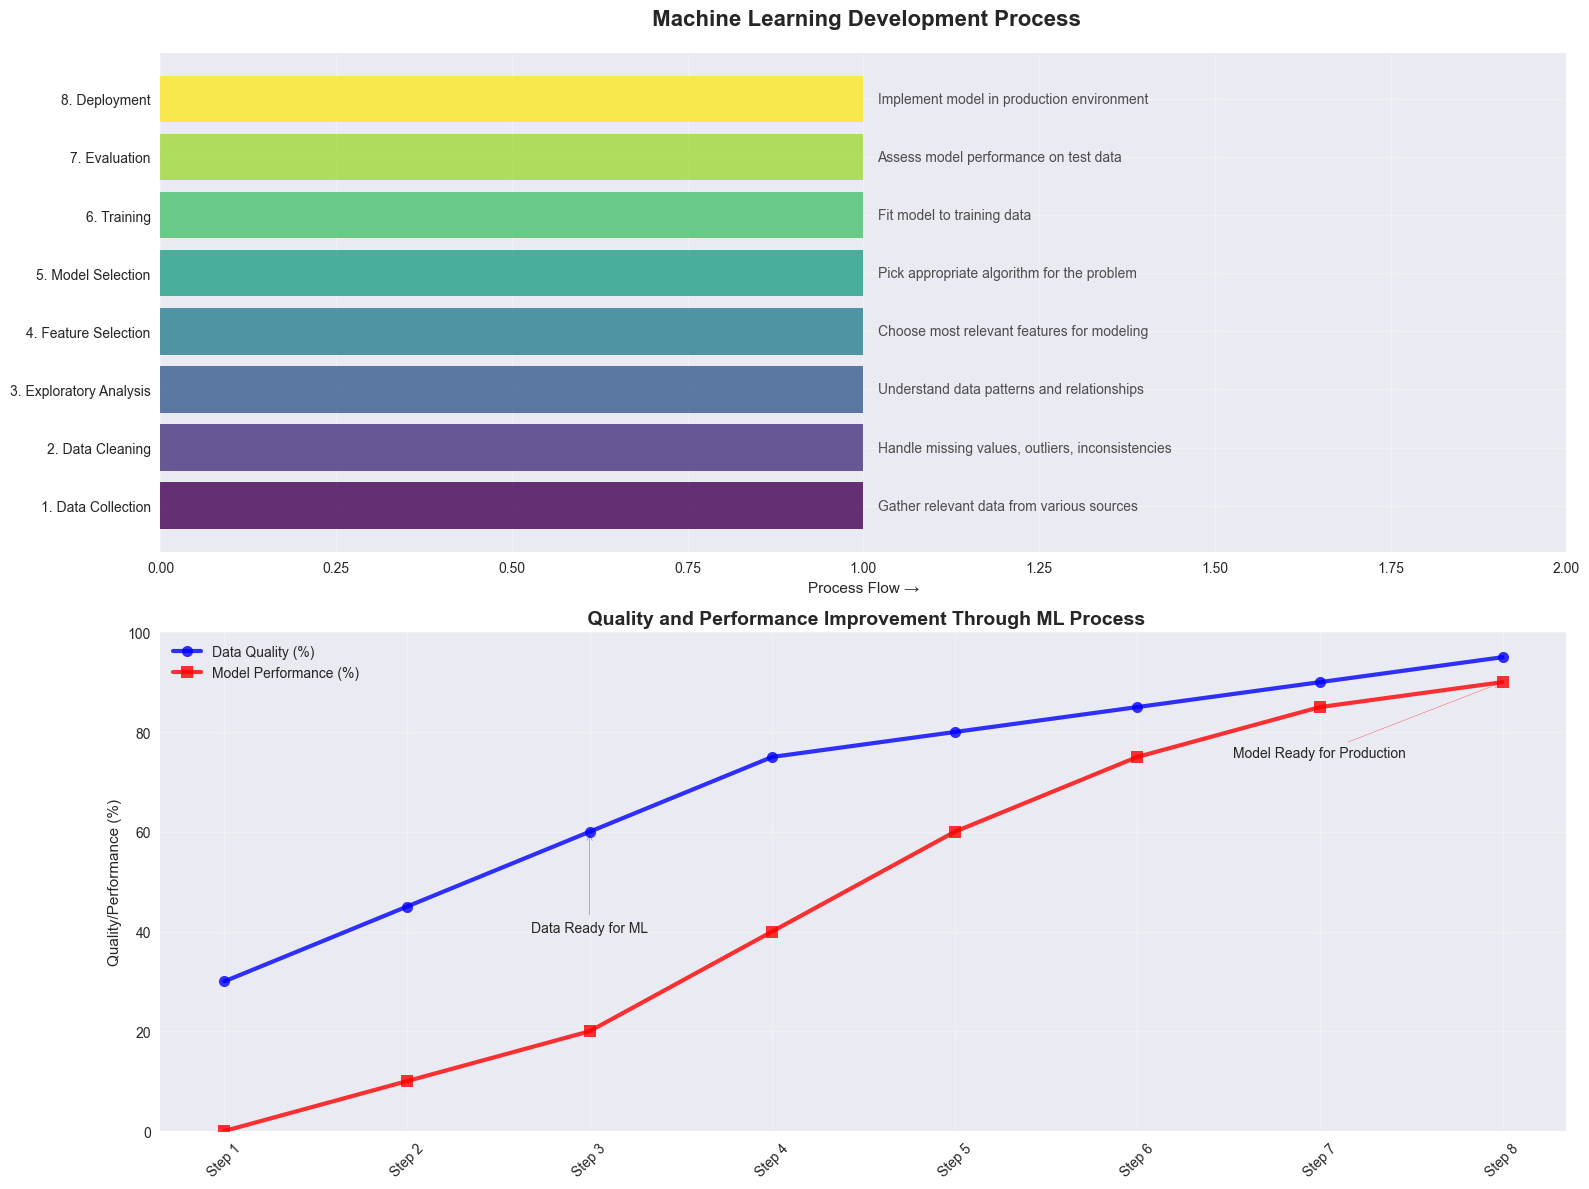

 DETAILED ML PROCESS BREAKDOWN

 1. Data Collection
------------------------------
Purpose: Gather relevant, high-quality data
Activities: Identify data sources, Extract data, Combine datasets
Output: Raw dataset
Time: 20-30% of project

 2. Data Cleaning
------------------------------
Purpose: Prepare data for analysis
Activities: Handle missing values, Remove outliers, Fix inconsistencies
Output: Clean dataset
Time: 20-25% of project

 3. Exploratory Analysis
------------------------------
Purpose: Understand data patterns
Activities: Statistical analysis, Visualization, Correlation analysis
Output: Data insights
Time: 15-20% of project

 4. Feature Selection
------------------------------
Purpose: Choose relevant variables
Activities: Feature importance, Correlation removal, Domain expertise
Output: Selected features
Time: 10-15% of project

 5. Model Selection
------------------------------
Purpose: Choose appropriate algorithm
Activities: Algorithm comparison, Hyperparameter tunin

In [5]:
ml_process_steps = [
    "1. Data Collection",
    "2. Data Cleaning",
    "3. Exploratory Analysis",
    "4. Feature Selection",
    "5. Model Selection",
    "6. Training",
    "7. Evaluation",
    "8. Deployment"
]

#  process timeline visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Timeline visualization
y_positions = range(len(ml_process_steps))
colors = plt.cm.viridis(np.linspace(0, 1, len(ml_process_steps)))

bars = ax1.barh(y_positions, [1]*len(ml_process_steps), color=colors, alpha=0.8)
ax1.set_yticks(y_positions)
ax1.set_yticklabels(ml_process_steps)
ax1.set_xlabel('Process Flow →')
ax1.set_title(' Machine Learning Development Process', fontsize=16, fontweight='bold', pad=20)

#  step numbers and descriptions
descriptions = [
    "Gather relevant data from various sources",
    "Handle missing values, outliers, inconsistencies",
    "Understand data patterns and relationships",
    "Choose most relevant features for modeling",
    "Pick appropriate algorithm for the problem",
    "Fit model to training data",
    "Assess model performance on test data",
    "Implement model in production environment"
]

for i, (bar, desc) in enumerate(zip(bars, descriptions)):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
             desc, va='center', fontsize=10, alpha=0.8)

ax1.set_xlim(0, 2)
ax1.grid(True, alpha=0.3)


np.random.seed(42)
data_quality = [30, 45, 60, 75, 80, 85, 90, 95]  
model_performance = [0, 10, 20, 40, 60, 75, 85, 90]  

ax2.plot(range(len(ml_process_steps)), data_quality, 'b-o', linewidth=3, 
         markersize=8, label='Data Quality (%)', alpha=0.8)
ax2.plot(range(len(ml_process_steps)), model_performance, 'r-s', linewidth=3, 
         markersize=8, label='Model Performance (%)', alpha=0.8)

ax2.set_xticks(range(len(ml_process_steps)))
ax2.set_xticklabels([f"Step {i+1}" for i in range(len(ml_process_steps))], rotation=45)
ax2.set_ylabel('Quality/Performance (%)')
ax2.set_title(' Quality and Performance Improvement Through ML Process', 
              fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

# Adding annotations for key milestones
ax2.annotate('Data Ready for ML', xy=(2, 60), xytext=(2, 40),
             arrowprops=dict(arrowstyle='->', color='blue', alpha=0.7),
             fontsize=10, ha='center')
ax2.annotate('Model Ready for Production', xy=(7, 90), xytext=(6, 75),
             arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
             fontsize=10, ha='center')

plt.tight_layout()
plt.show()

#  detailed process breakdown
print(" DETAILED ML PROCESS BREAKDOWN")
print("=" * 50)

process_details = {
    "1. Data Collection": {
        "Purpose": "Gather relevant, high-quality data",
        "Activities": ["Identify data sources", "Extract data", "Combine datasets"],
        "Output": "Raw dataset",
        "Time": "20-30% of project"
    },
    "2. Data Cleaning": {
        "Purpose": "Prepare data for analysis",
        "Activities": ["Handle missing values", "Remove outliers", "Fix inconsistencies"],
        "Output": "Clean dataset",
        "Time": "20-25% of project"
    },
    "3. Exploratory Analysis": {
        "Purpose": "Understand data patterns",
        "Activities": ["Statistical analysis", "Visualization", "Correlation analysis"],
        "Output": "Data insights",
        "Time": "15-20% of project"
    },
    "4. Feature Selection": {
        "Purpose": "Choose relevant variables",
        "Activities": ["Feature importance", "Correlation removal", "Domain expertise"],
        "Output": "Selected features",
        "Time": "10-15% of project"
    },
    "5. Model Selection": {
        "Purpose": "Choose appropriate algorithm",
        "Activities": ["Algorithm comparison", "Hyperparameter tuning", "Validation"],
        "Output": "Best model",
        "Time": "15-20% of project"
    },
    "6. Training": {
        "Purpose": "Fit model to data",
        "Activities": ["Split data", "Train algorithm", "Monitor convergence"],
        "Output": "Trained model",
        "Time": "5-10% of project"
    },
    "7. Evaluation": {
        "Purpose": "Assess model performance",
        "Activities": ["Test on unseen data", "Calculate metrics", "Validate results"],
        "Output": "Performance metrics",
        "Time": "10-15% of project"
    },
    "8. Deployment": {
        "Purpose": "Implement in production",
        "Activities": ["Setup infrastructure", "Monitor performance", "Maintain model"],
        "Output": "Production system",
        "Time": "Ongoing"
    }
}

for step, details in process_details.items():
    print(f"\n {step}")
    print("-" * 30)
    for key, value in details.items():
        if isinstance(value, list):
            print(f"{key}: {', '.join(value)}")
        else:
            print(f"{key}: {value}")

print(f"\n KEY INSIGHTS:")
print(f" Data preparation takes 60-70% of total project time")
print(f" Model development is only 20-30% of the work")
print(f" Deployment and maintenance are ongoing responsibilities")
print(f" Quality improves at each step of the process")
print(f" Iteration and refinement are essential for success")

## 6. Feature Selection Techniques {#features}

Feature selection is crucial for building effective ML models. It helps reduce overfitting, improve performance, and reduce computational costs. Let's explore various techniques:

 FEATURE SELECTION TECHNIQUES DEMONSTRATION
Dataset: Breast Cancer Wisconsin
Original features: 30
Samples: 569

1 CORRELATION-BASED SELECTION:
   Found 44 highly correlated pairs (>0.8)
   • mean radius          ↔ mean perimeter       (r=0.998)
   • mean radius          ↔ mean area            (r=0.987)
   • mean radius          ↔ mean concave points  (r=0.823)
   • mean radius          ↔ worst radius         (r=0.970)
   • mean radius          ↔ worst perimeter      (r=0.965)

2 CHI-SQUARE STATISTICAL SELECTION:
   Selected top 10 features
   Top 5 features by chi-square score:
   • mean radius               (score: 266.10)
   • mean texture              (score: 93.90)
   • mean perimeter            (score: 2011.10)
   • mean area                 (score: 53991.66)
   • perimeter error           (score: 250.57)

3 RECURSIVE FEATURE ELIMINATION (RFE):
   Selected 10 features
   Selected features (rank 1):
   • mean area                
   • mean concavity           
   • mean concave po

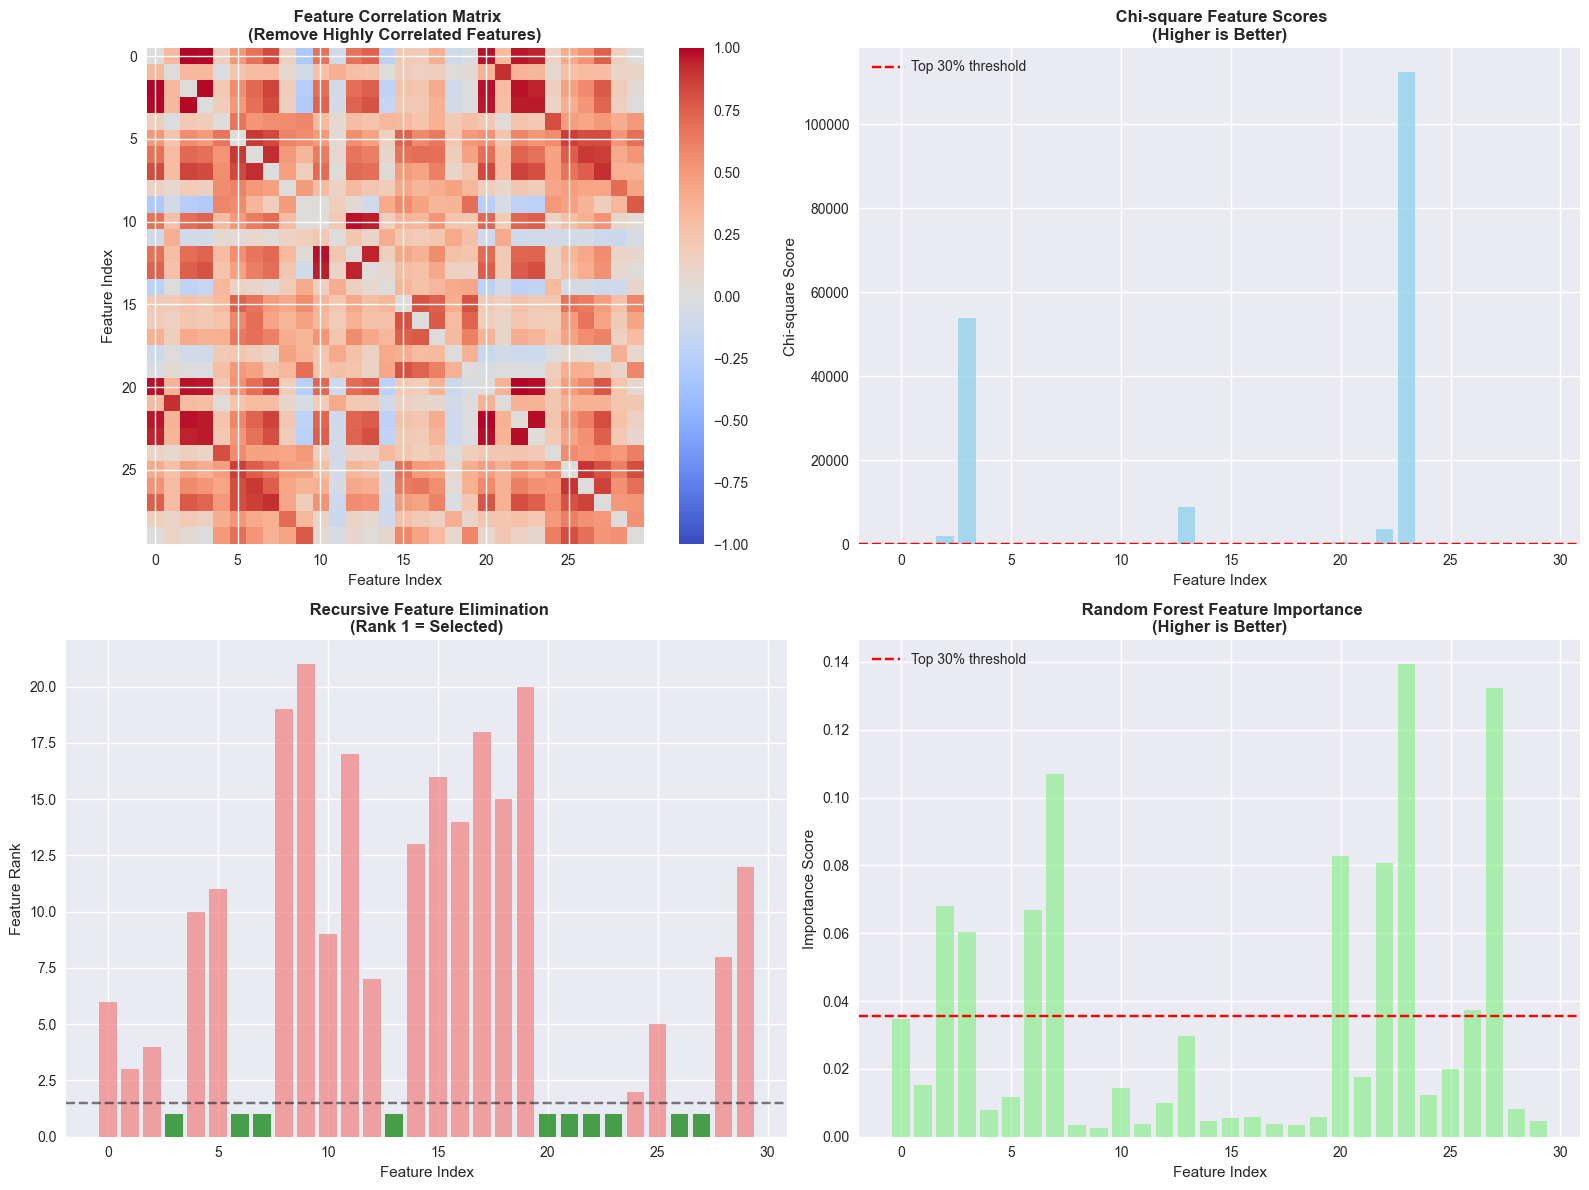


 PERFORMANCE COMPARISON
Method                 | Features | Accuracy
---------------------------------------------
All Features         |    30    | 95.6%
Chi-square           |    10    | 96.5%
RFE                  |    10    | 96.5%

 KEY INSIGHTS:
 Feature selection can maintain or improve performance with fewer features
 Different methods may select different features - domain knowledge helps
 Fewer features = faster training, less overfitting, better interpretability
 Always validate feature selection on separate test data

 FEATURE SELECTION BENEFITS:
 Improved Performance: Remove noise and irrelevant features
 Faster Training: Fewer dimensions = faster computation
 Reduced Storage: Less memory required for models
 Better Interpretability: Focus on most important variables
 Reduced Overfitting: Less complex models generalize better


In [6]:

cancer_data = load_breast_cancer()
X_cancer = cancer_data.data
y_cancer = cancer_data.target
feature_names = cancer_data.feature_names

print(" FEATURE SELECTION TECHNIQUES DEMONSTRATION")
print("=" * 55)
print(f"Dataset: Breast Cancer Wisconsin")
print(f"Original features: {X_cancer.shape[1]}")
print(f"Samples: {X_cancer.shape[0]}")

#  visualization comparing different feature selection methods
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Correlation-based Feature Selection
correlation_matrix = np.corrcoef(X_cancer.T)
np.fill_diagonal(correlation_matrix, 0)  # Remove self-correlation

# Finding highly correlated feature pairs
high_corr_threshold = 0.8
high_corr_pairs = []
for i in range(len(correlation_matrix)):
    for j in range(i+1, len(correlation_matrix)):
        if abs(correlation_matrix[i, j]) > high_corr_threshold:
            high_corr_pairs.append((i, j, correlation_matrix[i, j]))

# Visualize correlation matrix
im1 = ax1.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax1.set_title(' Feature Correlation Matrix\n(Remove Highly Correlated Features)', fontweight='bold')
ax1.set_xlabel('Feature Index')
ax1.set_ylabel('Feature Index')
plt.colorbar(im1, ax=ax1)

print(f"\n1 CORRELATION-BASED SELECTION:")
print(f"   Found {len(high_corr_pairs)} highly correlated pairs (>{high_corr_threshold})")
features_to_remove = set()
for i, j, corr in high_corr_pairs[:5]:  # Show first 5
    print(f"   • {feature_names[i][:20]:<20} ↔ {feature_names[j][:20]:<20} (r={corr:.3f})")
    features_to_remove.add(j)  # Remove second feature in pair

# 2. Statistical Feature Selection (Chi-square)
selector_chi2 = SelectKBest(score_func=chi2, k=10)
X_selected_chi2 = selector_chi2.fit_transform(X_cancer, y_cancer)
chi2_scores = selector_chi2.scores_
selected_features_chi2 = selector_chi2.get_support(indices=True)

# Plot chi-square scores
ax2.bar(range(len(chi2_scores)), chi2_scores, alpha=0.7, color='skyblue')
ax2.axhline(y=np.percentile(chi2_scores, 70), color='red', linestyle='--', 
           label=f'Top 30% threshold')
ax2.set_title(' Chi-square Feature Scores\n(Higher is Better)', fontweight='bold')
ax2.set_xlabel('Feature Index')
ax2.set_ylabel('Chi-square Score')
ax2.legend()

print(f"\n2 CHI-SQUARE STATISTICAL SELECTION:")
print(f"   Selected top {len(selected_features_chi2)} features")
print(f"   Top 5 features by chi-square score:")
top_chi2_indices = selected_features_chi2[:5]
for idx in top_chi2_indices:
    print(f"   • {feature_names[idx]:<25} (score: {chi2_scores[idx]:.2f})")

# 3. Recursive Feature Elimination (RFE)
estimator = RandomForestClassifier(n_estimators=50, random_state=42)
selector_rfe = RFE(estimator, n_features_to_select=10, step=1)
X_selected_rfe = selector_rfe.fit_transform(X_cancer, y_cancer)
rfe_ranking = selector_rfe.ranking_
selected_features_rfe = selector_rfe.get_support(indices=True)

# Plot RFE ranking
colors_rfe = ['green' if r == 1 else 'lightcoral' for r in rfe_ranking]
ax3.bar(range(len(rfe_ranking)), rfe_ranking, color=colors_rfe, alpha=0.7)
ax3.set_title(' Recursive Feature Elimination\n(Rank 1 = Selected)', fontweight='bold')
ax3.set_xlabel('Feature Index')
ax3.set_ylabel('Feature Rank')
ax3.axhline(y=1.5, color='black', linestyle='--', alpha=0.5)

print(f"\n3 RECURSIVE FEATURE ELIMINATION (RFE):")
print(f"   Selected {len(selected_features_rfe)} features")
print(f"   Selected features (rank 1):")
for idx in selected_features_rfe[:5]:
    print(f"   • {feature_names[idx]:<25}")

# 4. Model-based Feature Importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_cancer, y_cancer)
feature_importance = rf_model.feature_importances_

# Get top features by importance
importance_indices = np.argsort(feature_importance)[::-1]
top_10_features = importance_indices[:10]

ax4.bar(range(len(feature_importance)), feature_importance, alpha=0.7, color='lightgreen')
ax4.axhline(y=np.percentile(feature_importance, 70), color='red', linestyle='--', 
           label='Top 30% threshold')
ax4.set_title(' Random Forest Feature Importance\n(Higher is Better)', fontweight='bold')
ax4.set_xlabel('Feature Index')
ax4.set_ylabel('Importance Score')
ax4.legend()

print(f"\n4 MODEL-BASED FEATURE IMPORTANCE:")
print(f"   Top 5 most important features:")
for i, idx in enumerate(top_10_features[:5]):
    print(f"   {i+1}. {feature_names[idx]:<25} (importance: {feature_importance[idx]:.4f})")

plt.tight_layout()
plt.show()

# Compare performance with different feature selection methods
print(f"\n PERFORMANCE COMPARISON")
print("=" * 35)

# Original data
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X_cancer, y_cancer, 
                                                             test_size=0.2, random_state=42)
model_orig = LogisticRegression(random_state=42, max_iter=1000)
model_orig.fit(X_train_orig, y_train)
accuracy_orig = model_orig.score(X_test_orig, y_test)

# Chi-square selected features
X_train_chi2, X_test_chi2, _, _ = train_test_split(X_selected_chi2, y_cancer, 
                                                  test_size=0.2, random_state=42)
model_chi2 = LogisticRegression(random_state=42, max_iter=1000)
model_chi2.fit(X_train_chi2, y_train)
accuracy_chi2 = model_chi2.score(X_test_chi2, y_test)

# RFE selected features
X_train_rfe, X_test_rfe, _, _ = train_test_split(X_selected_rfe, y_cancer, 
                                                test_size=0.2, random_state=42)
model_rfe = LogisticRegression(random_state=42, max_iter=1000)
model_rfe.fit(X_train_rfe, y_train)
accuracy_rfe = model_rfe.score(X_test_rfe, y_test)

# Performance comparison
methods = ['All Features\n(30)', 'Chi-square\n(10)', 'RFE\n(10)']
accuracies = [accuracy_orig, accuracy_chi2, accuracy_rfe]
feature_counts = [30, 10, 10]

print(f"Method                 | Features | Accuracy")
print(f"-" * 45)
for method, features, acc in zip(methods, feature_counts, accuracies):
    method_clean = method.split('\n')[0]
    print(f"{method_clean:<20} | {features:^8} | {acc:.1%}")

print(f"\n KEY INSIGHTS:")
print(f" Feature selection can maintain or improve performance with fewer features")
print(f" Different methods may select different features - domain knowledge helps")
print(f" Fewer features = faster training, less overfitting, better interpretability")
print(f" Always validate feature selection on separate test data")

# Summary of feature selection benefits
print(f"\n FEATURE SELECTION BENEFITS:")
print(f" Improved Performance: Remove noise and irrelevant features")
print(f" Faster Training: Fewer dimensions = faster computation")
print(f" Reduced Storage: Less memory required for models")
print(f" Better Interpretability: Focus on most important variables")
print(f" Reduced Overfitting: Less complex models generalize better")

## 7. Model Selection Methods {#models}

Model selection is critical for finding the best algorithm and parameters for your specific problem. Let's explore various approaches to choose the optimal model:

 MODEL SELECTION METHODS DEMONSTRATION
Dataset: Iris flower classification
Features: 4 (sepal/petal length and width)
Classes: 3 (setosa, versicolor, virginica)
Samples: 150

1 CROSS-VALIDATION COMPARISON:
-----------------------------------
Logistic Regression: 0.973 (±0.025)
Decision Tree     : 0.953 (±0.034)
Random Forest     : 0.967 (±0.021)
SVM               : 0.967 (±0.021)

2 LEARNING CURVES ANALYSIS:
------------------------------
Final training accuracy: 1.000
Final validation accuracy: 0.967
Gap (potential overfitting): 0.033

3 HYPERPARAMETER TUNING:
----------------------------
Best parameters: n_estimators=30, max_depth=4
Best CV score: 0.967

4 MODEL COMPLEXITY ANALYSIS:
--------------------------------
Optimal complexity (max_depth): 3
Best test accuracy: 1.000


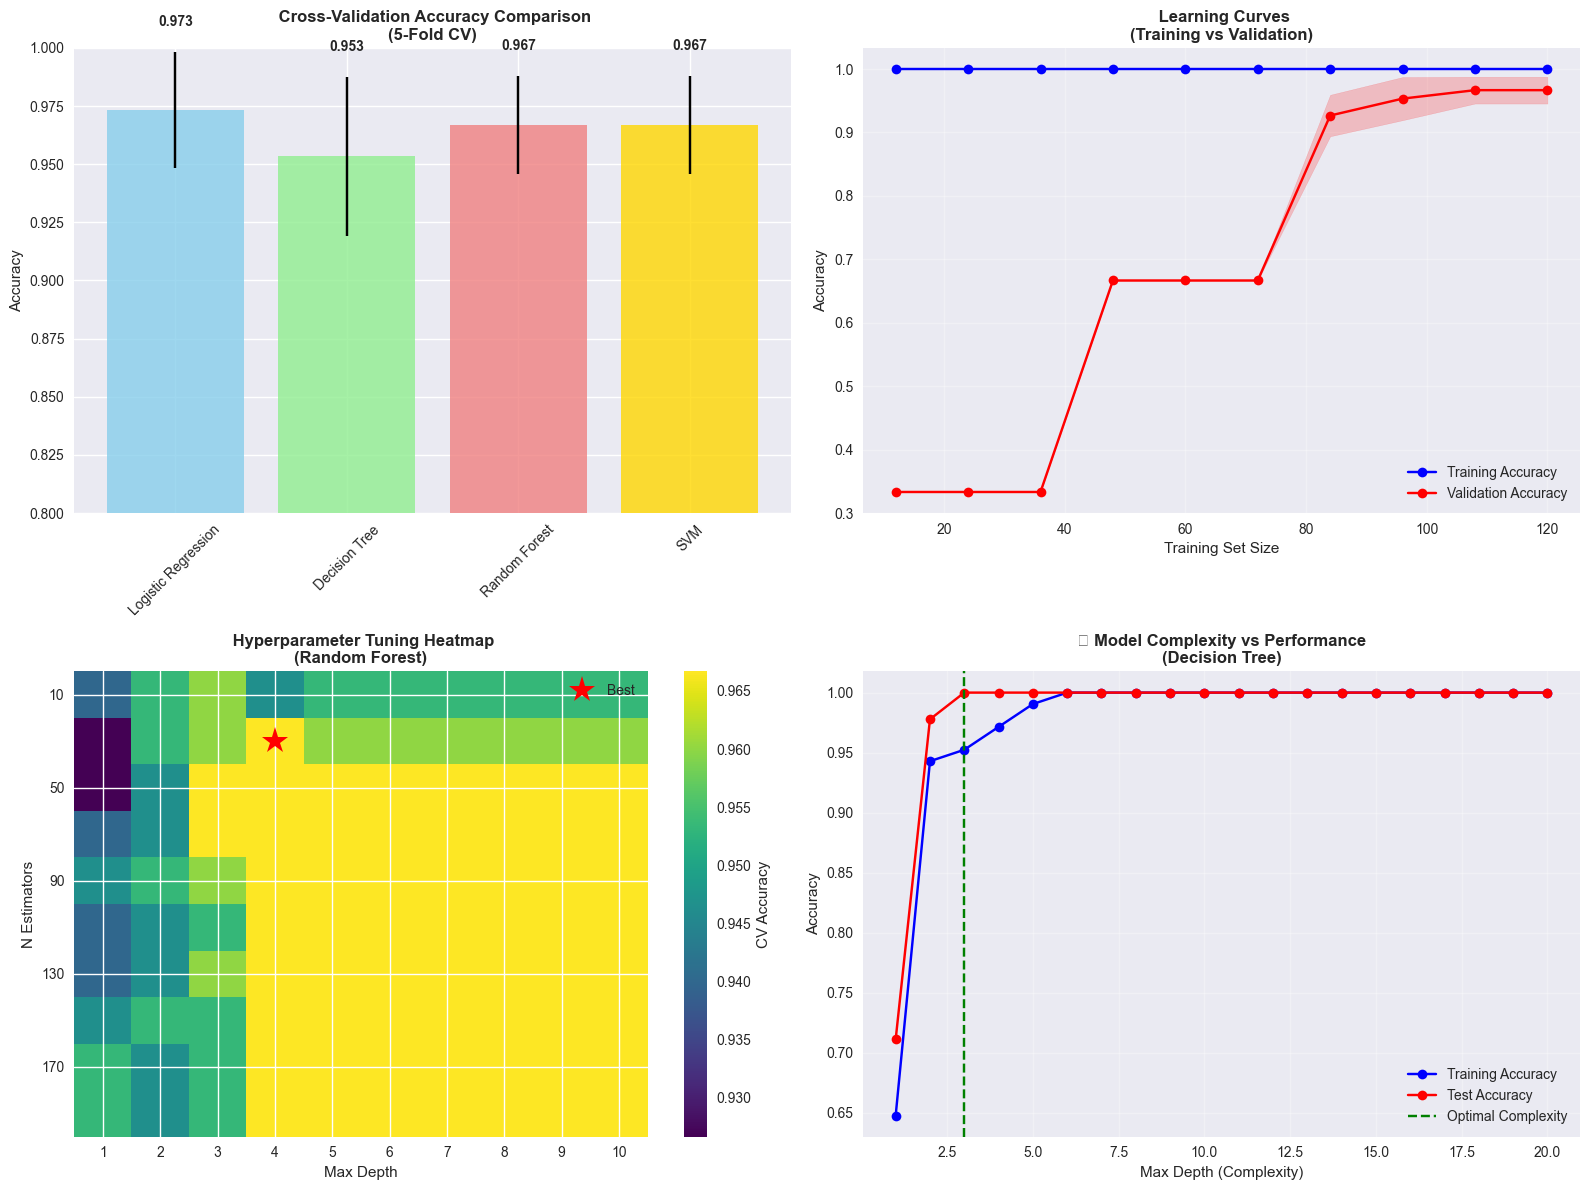


 MODEL SELECTION STRATEGY SUMMARY

1. Baseline Models
Purpose: Establish performance benchmarks
Approach: Simple models (logistic regression, decision tree)
Benefit: Quick implementation, interpretable results

2. Cross-Validation
Purpose: Robust performance estimation
Approach: K-fold CV, stratified sampling
Benefit: Reduces overfitting, stable metrics

3. Hyperparameter Tuning
Purpose: Optimize model performance
Approach: Grid search, random search, Bayesian optimization
Benefit: Maximize model potential

4. Complexity Analysis
Purpose: Balance bias-variance tradeoff
Approach: Learning curves, validation curves
Benefit: Prevent overfitting/underfitting

5. Ensemble Methods
Purpose: Combine multiple models
Approach: Voting, bagging, boosting
Benefit: Often better than single models

🎯 BEST PRACTICES:
✅ Start with simple baseline models
✅ Use cross-validation for all comparisons
✅ Tune hyperparameters systematically
✅ Monitor for overfitting vs underfitting
✅ Consider ensemble methods

In [7]:
print(" MODEL SELECTION METHODS DEMONSTRATION")
print("=" * 50)

# Load dataset for model comparison
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

print(f"Dataset: Iris flower classification")
print(f"Features: {X_iris.shape[1]} (sepal/petal length and width)")
print(f"Classes: {len(np.unique(y_iris))} (setosa, versicolor, virginica)")
print(f"Samples: {X_iris.shape[0]}")

# Define multiple models to compare
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': None  
}

try:
    from sklearn.svm import SVC
    models['SVM'] = SVC(random_state=42, probability=True)
except ImportError:
    print("SVM not available, using 3 models for comparison")
    del models['SVM']

#  comprehensive model comparison visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Cross-Validation Scores Comparison
print(f"\n1 CROSS-VALIDATION COMPARISON:")
print("-" * 35)

cv_scores = {}
cv_means = {}
cv_stds = {}

for name, model in models.items():
    if model is not None:
        scores = cross_val_score(model, X_iris, y_iris, cv=5, scoring='accuracy')
        cv_scores[name] = scores
        cv_means[name] = scores.mean()
        cv_stds[name] = scores.std()
        print(f"{name:<18}: {scores.mean():.3f} (±{scores.std():.3f})")

# Plot cross-validation results
model_names = list(cv_means.keys())
means = list(cv_means.values())
stds = list(cv_stds.values())

bars = ax1.bar(model_names, means, yerr=stds, capsize=5, alpha=0.8, 
               color=['skyblue', 'lightgreen', 'lightcoral', 'gold'][:len(model_names)])
ax1.set_title(' Cross-Validation Accuracy Comparison\n(5-Fold CV)', fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.8, 1.0)
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, mean, std in zip(bars, means, stds):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + std + 0.01,
             f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')

# 2. Training vs Validation Curves (Learning Curves)
print(f"\n2 LEARNING CURVES ANALYSIS:")
print("-" * 30)

from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.1, 1.0, 10)
best_model = RandomForestClassifier(n_estimators=100, random_state=42)

train_sizes_abs, train_scores, val_scores = learning_curve(
    best_model, X_iris, y_iris, train_sizes=train_sizes, cv=5, 
    scoring='accuracy', random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

ax2.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Training Accuracy')
ax2.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, 
                 alpha=0.2, color='blue')
ax2.plot(train_sizes_abs, val_mean, 'o-', color='red', label='Validation Accuracy')
ax2.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, 
                 alpha=0.2, color='red')

ax2.set_title(' Learning Curves\n(Training vs Validation)', fontweight='bold')
ax2.set_xlabel('Training Set Size')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

print(f"Final training accuracy: {train_mean[-1]:.3f}")
print(f"Final validation accuracy: {val_mean[-1]:.3f}")
print(f"Gap (potential overfitting): {train_mean[-1] - val_mean[-1]:.3f}")

# 3. Hyperparameter Tuning Simulation
print(f"\n3 HYPERPARAMETER TUNING:")
print("-" * 28)

# Simulate hyperparameter tuning for Random Forest
n_estimators_range = range(10, 201, 20)
max_depth_range = range(1, 11)

# Create a grid of hyperparameter combinations
param_scores = []
param_combinations = []

for n_est in n_estimators_range:
    for max_dep in max_depth_range:
        rf_model = RandomForestClassifier(n_estimators=n_est, max_depth=max_dep, random_state=42)
        scores = cross_val_score(rf_model, X_iris, y_iris, cv=3)
        param_scores.append(scores.mean())
        param_combinations.append((n_est, max_dep))

# Find best parameters
best_idx = np.argmax(param_scores)
best_params = param_combinations[best_idx]
best_score = param_scores[best_idx]

print(f"Best parameters: n_estimators={best_params[0]}, max_depth={best_params[1]}")
print(f"Best CV score: {best_score:.3f}")

# Visualize hyperparameter tuning results
param_grid = np.array(param_scores).reshape(len(n_estimators_range), len(max_depth_range))
im = ax3.imshow(param_grid, cmap='viridis', aspect='auto')
ax3.set_title(' Hyperparameter Tuning Heatmap\n(Random Forest)', fontweight='bold')
ax3.set_xlabel('Max Depth')
ax3.set_ylabel('N Estimators')
ax3.set_xticks(range(len(max_depth_range)))
ax3.set_xticklabels(max_depth_range)
ax3.set_yticks(range(0, len(n_estimators_range), 2))
ax3.set_yticklabels(n_estimators_range[::2])
plt.colorbar(im, ax=ax3, label='CV Accuracy')

# Mark best parameters
best_depth_idx = max_depth_range.index(best_params[1])
best_n_est_idx = list(n_estimators_range).index(best_params[0])
ax3.plot(best_depth_idx, best_n_est_idx, 'r*', markersize=20, label='Best')
ax3.legend()

# 4. Model Complexity vs Performance
print(f"\n4 MODEL COMPLEXITY ANALYSIS:")
print("-" * 32)

# Analyze different model complexities
complexity_range = range(1, 21)
train_accuracies = []
test_accuracies = []

X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

for depth in complexity_range:
    dt_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_model.fit(X_train, y_train)
    
    train_acc = dt_model.score(X_train, y_train)
    test_acc = dt_model.score(X_test, y_test)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

ax4.plot(complexity_range, train_accuracies, 'o-', label='Training Accuracy', color='blue')
ax4.plot(complexity_range, test_accuracies, 'o-', label='Test Accuracy', color='red')
ax4.axvline(x=complexity_range[np.argmax(test_accuracies)], color='green', 
           linestyle='--', label='Optimal Complexity')

ax4.set_title('🎯 Model Complexity vs Performance\n(Decision Tree)', fontweight='bold')
ax4.set_xlabel('Max Depth (Complexity)')
ax4.set_ylabel('Accuracy')
ax4.legend()
ax4.grid(True, alpha=0.3)

optimal_depth = complexity_range[np.argmax(test_accuracies)]
print(f"Optimal complexity (max_depth): {optimal_depth}")
print(f"Best test accuracy: {max(test_accuracies):.3f}")

plt.tight_layout()
plt.show()

# Model Selection Strategy Summary
print(f"\n MODEL SELECTION STRATEGY SUMMARY")
print("=" * 45)

selection_strategies = {
    "1. Baseline Models": {
        "Purpose": "Establish performance benchmarks",
        "Approach": "Simple models (logistic regression, decision tree)",
        "Benefit": "Quick implementation, interpretable results"
    },
    "2. Cross-Validation": {
        "Purpose": "Robust performance estimation",
        "Approach": "K-fold CV, stratified sampling",
        "Benefit": "Reduces overfitting, stable metrics"
    },
    "3. Hyperparameter Tuning": {
        "Purpose": "Optimize model performance",
        "Approach": "Grid search, random search, Bayesian optimization",
        "Benefit": "Maximize model potential"
    },
    "4. Complexity Analysis": {
        "Purpose": "Balance bias-variance tradeoff",
        "Approach": "Learning curves, validation curves",
        "Benefit": "Prevent overfitting/underfitting"
    },
    "5. Ensemble Methods": {
        "Purpose": "Combine multiple models",
        "Approach": "Voting, bagging, boosting",
        "Benefit": "Often better than single models"
    }
}

for strategy, details in selection_strategies.items():
    print(f"\n{strategy}")
    print(f"Purpose: {details['Purpose']}")
    print(f"Approach: {details['Approach']}")
    print(f"Benefit: {details['Benefit']}")

print(f"\n🎯 BEST PRACTICES:")
print(f"✅ Start with simple baseline models")
print(f"✅ Use cross-validation for all comparisons")
print(f"✅ Tune hyperparameters systematically")
print(f"✅ Monitor for overfitting vs underfitting")
print(f"✅ Consider ensemble methods for final models")
print(f"✅ Always validate on truly unseen test data")

## 8. Model Evaluation Metrics {#evaluation}

Model evaluation is essential to understand how well your model performs. Different metrics provide different insights into model behavior:

🎯 MODEL EVALUATION METRICS DEMONSTRATION
Dataset: Breast Cancer Classification
Classes: Malignant (1) vs Benign (0)
Test set size: 171 samples

 CONFUSION MATRIX BREAKDOWN:
True Negatives (TN):  59 - Correctly predicted benign
False Positives (FP): 4 - Incorrectly predicted malignant
False Negatives (FN): 1 - Incorrectly predicted benign
True Positives (TP):  107 - Correctly predicted malignant

 CLASSIFICATION METRICS:
Accuracy:  0.971 - Overall correctness
Precision: 0.964 - Positive prediction reliability
Recall:    0.991 - True positive detection rate
F1-Score:  0.977 - Harmonic mean of precision and recall

 ROC ANALYSIS:
AUC Score: 0.997
Model Performance: Excellent

 PRECISION-RECALL ANALYSIS:
Average Precision: 0.998


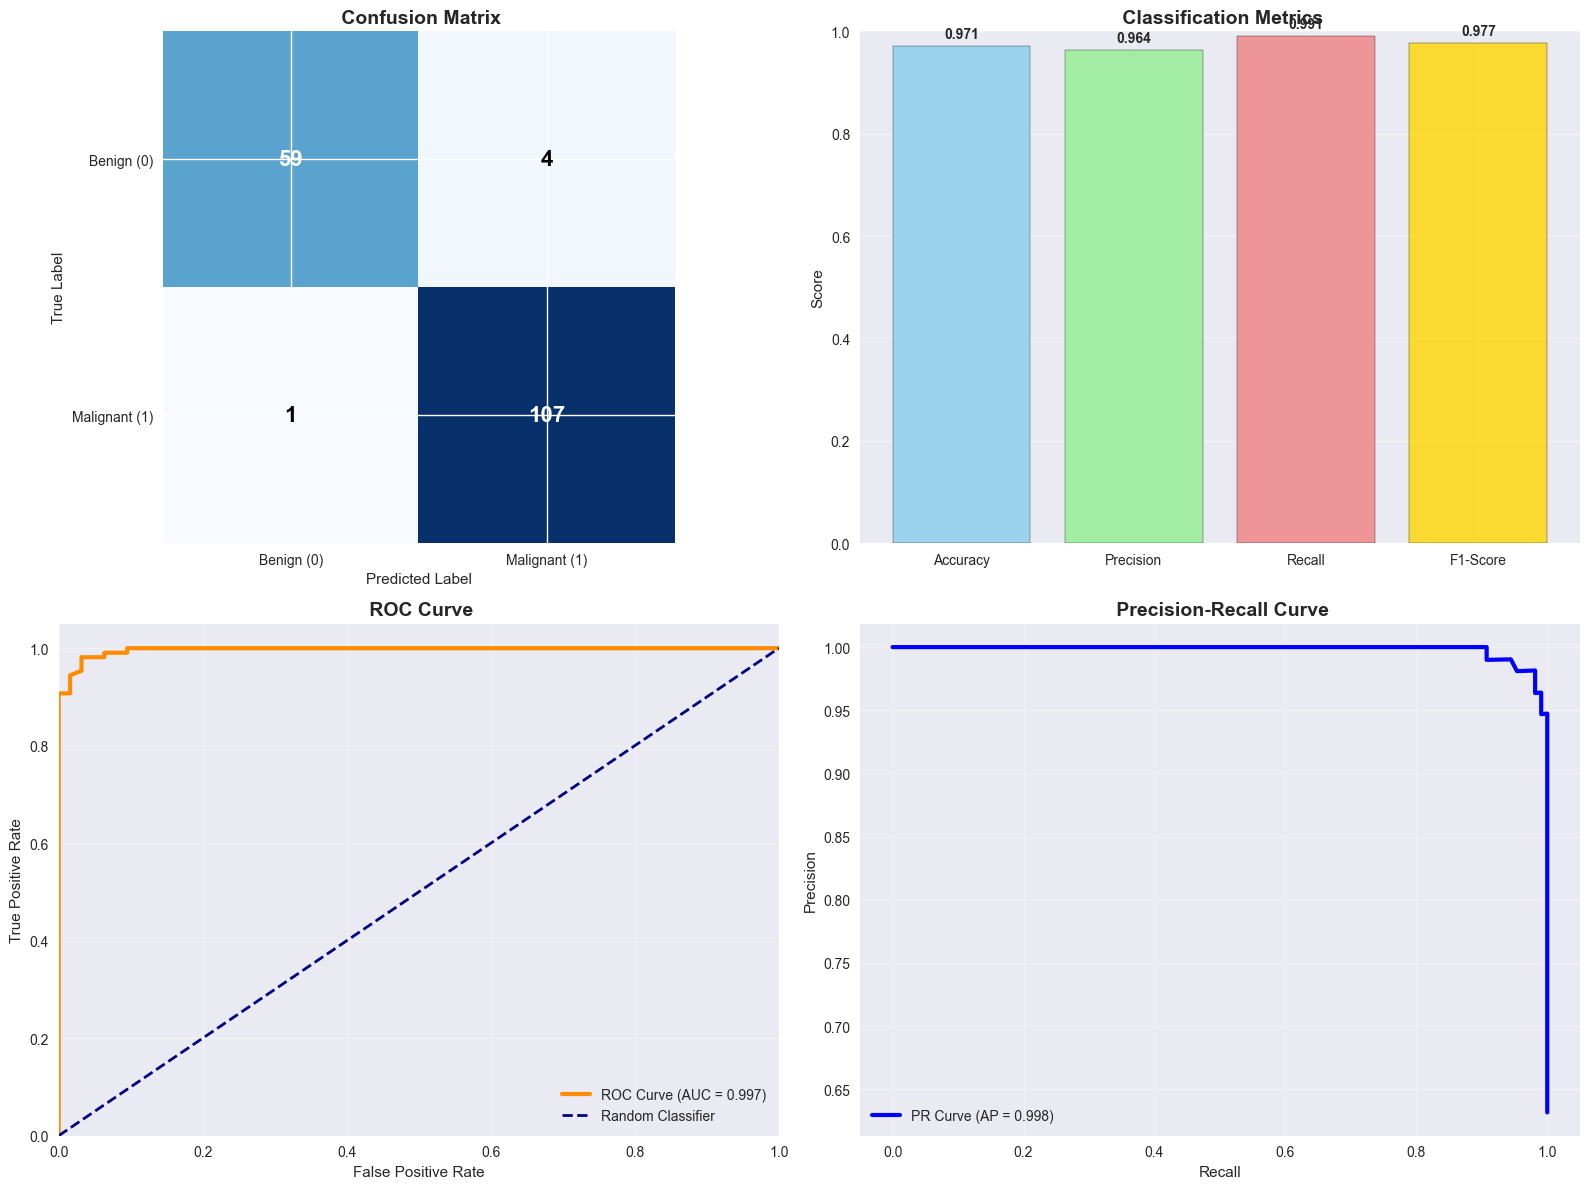


 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Benign       0.98      0.94      0.96        63
   Malignant       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171


 MANUAL METRICS VERIFICATION:
Manual Accuracy:  0.971 ✅ (matches: True)
Manual Precision: 0.964 ✅ (matches: True)
Manual Recall:    0.991 ✅ (matches: True)
Manual F1-Score:  0.977 ✅ (matches: True)

 WHEN TO USE EACH METRIC:

Accuracy:
  Use when: Balanced classes, overall performance matters
  Avoid when: Imbalanced classes (e.g., 95% vs 5%)
  Example: General classification problems

Precision:
  Use when: False positives are costly
  Avoid when: Missing true positives is more harmful
  Example: Spam detection (don't want important emails in spam)

Recall:
  Use when: False negatives are costly
  Avoid when: False positives are 

In [8]:

print("🎯 MODEL EVALUATION METRICS DEMONSTRATION")
print("=" * 50)

# Load binary classification dataset for detailed evaluation
cancer_data = load_breast_cancer()
X_cancer, y_cancer = cancer_data.data, cancer_data.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, 
                                                    test_size=0.3, random_state=42)

# Train a model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of positive class

print(f"Dataset: Breast Cancer Classification")
print(f"Classes: Malignant (1) vs Benign (0)")
print(f"Test set size: {len(y_test)} samples")

# Create comprehensive evaluation visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Benign (0)', 'Malignant (1)']

im1 = ax1.imshow(cm, interpolation='nearest', cmap='Blues')
ax1.set_title(' Confusion Matrix', fontweight='bold', fontsize=14)

# Add text annotations
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    ax1.text(j, i, format(cm[i, j], 'd'),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black",
             fontsize=16, fontweight='bold')

ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')
ax1.set_xticks(range(2))
ax1.set_yticks(range(2))
ax1.set_xticklabels(labels)
ax1.set_yticklabels(labels)

# Calculate metrics from confusion matrix
TN, FP, FN, TP = cm.ravel()
print(f"\n CONFUSION MATRIX BREAKDOWN:")
print(f"True Negatives (TN):  {TN} - Correctly predicted benign")
print(f"False Positives (FP): {FP} - Incorrectly predicted malignant")
print(f"False Negatives (FN): {FN} - Incorrectly predicted benign")
print(f"True Positives (TP):  {TP} - Correctly predicted malignant")

# 2. Classification Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
colors = ['skyblue', 'lightgreen', 'lightcoral', 'gold']

bars = ax2.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black')
ax2.set_title(' Classification Metrics', fontweight='bold', fontsize=14)
ax2.set_ylabel('Score')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

print(f"\n CLASSIFICATION METRICS:")
print(f"Accuracy:  {accuracy:.3f} - Overall correctness")
print(f"Precision: {precision:.3f} - Positive prediction reliability")
print(f"Recall:    {recall:.3f} - True positive detection rate")
print(f"F1-Score:  {f1:.3f} - Harmonic mean of precision and recall")

# 3. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

ax3.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title(' ROC Curve', fontweight='bold', fontsize=14)
ax3.legend(loc="lower right")
ax3.grid(True, alpha=0.3)

print(f"\n ROC ANALYSIS:")
print(f"AUC Score: {roc_auc:.3f}")
if roc_auc > 0.9:
    interpretation = "Excellent"
elif roc_auc > 0.8:
    interpretation = "Good"
elif roc_auc > 0.7:
    interpretation = "Fair"
else:
    interpretation = "Poor"
print(f"Model Performance: {interpretation}")

# 4. Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

ax4.plot(recall_vals, precision_vals, color='blue', lw=3, 
         label=f'PR Curve (AP = {avg_precision:.3f})')
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title(' Precision-Recall Curve', fontweight='bold', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)

print(f"\n PRECISION-RECALL ANALYSIS:")
print(f"Average Precision: {avg_precision:.3f}")

plt.tight_layout()
plt.show()

# Detailed classification report
print(f"\n DETAILED CLASSIFICATION REPORT:")
print("=" * 45)
target_names = ['Benign', 'Malignant']
report = classification_report(y_test, y_pred, target_names=target_names)
print(report)

# Custom metrics calculation to verify understanding
print(f"\n MANUAL METRICS VERIFICATION:")
print("=" * 35)

# Calculate metrics manually
manual_accuracy = (TP + TN) / (TP + TN + FP + FN)
manual_precision = TP / (TP + FP) if (TP + FP) > 0 else 0
manual_recall = TP / (TP + FN) if (TP + FN) > 0 else 0
manual_f1 = 2 * (manual_precision * manual_recall) / (manual_precision + manual_recall) if (manual_precision + manual_recall) > 0 else 0

print(f"Manual Accuracy:  {manual_accuracy:.3f} ✅ (matches: {abs(manual_accuracy - accuracy) < 0.001})")
print(f"Manual Precision: {manual_precision:.3f} ✅ (matches: {abs(manual_precision - precision) < 0.001})")
print(f"Manual Recall:    {manual_recall:.3f} ✅ (matches: {abs(manual_recall - recall) < 0.001})")
print(f"Manual F1-Score:  {manual_f1:.3f} ✅ (matches: {abs(manual_f1 - f1) < 0.001})")

# When to use which metric
print(f"\n WHEN TO USE EACH METRIC:")
print("=" * 30)

metric_guidance = {
    "Accuracy": {
        "Use when": "Balanced classes, overall performance matters",
        "Avoid when": "Imbalanced classes (e.g., 95% vs 5%)",
        "Example": "General classification problems"
    },
    "Precision": {
        "Use when": "False positives are costly",
        "Avoid when": "Missing true positives is more harmful",
        "Example": "Spam detection (don't want important emails in spam)"
    },
    "Recall": {
        "Use when": "False negatives are costly",
        "Avoid when": "False positives are more harmful",
        "Example": "Cancer detection (don't miss any cancer cases)"
    },
    "F1-Score": {
        "Use when": "Need balance between precision and recall",
        "Avoid when": "One metric is clearly more important",
        "Example": "Information retrieval systems"
    },
    "ROC-AUC": {
        "Use when": "Ranking/probability predictions important",
        "Avoid when": "Heavily imbalanced classes",
        "Example": "Credit scoring, recommendation systems"
    }
}

for metric, info in metric_guidance.items():
    print(f"\n{metric}:")
    for key, value in info.items():
        print(f"  {key}: {value}")

print(f"\n💡 KEY INSIGHTS:")
print(f"✅ No single metric tells the whole story")
print(f"✅ Choose metrics based on business objectives")
print(f"✅ Consider the cost of different types of errors")
print(f"✅ Use multiple metrics for comprehensive evaluation")
print(f"✅ Visualizations (ROC, PR curves) provide additional insights")

## 9. Creating ML Process Flowchart {#flowchart}

Let's create a comprehensive visual flowchart that shows the complete Machine Learning process from start to finish:

 MACHINE LEARNING PROCESS FLOWCHART
Creating comprehensive visual flowchart...


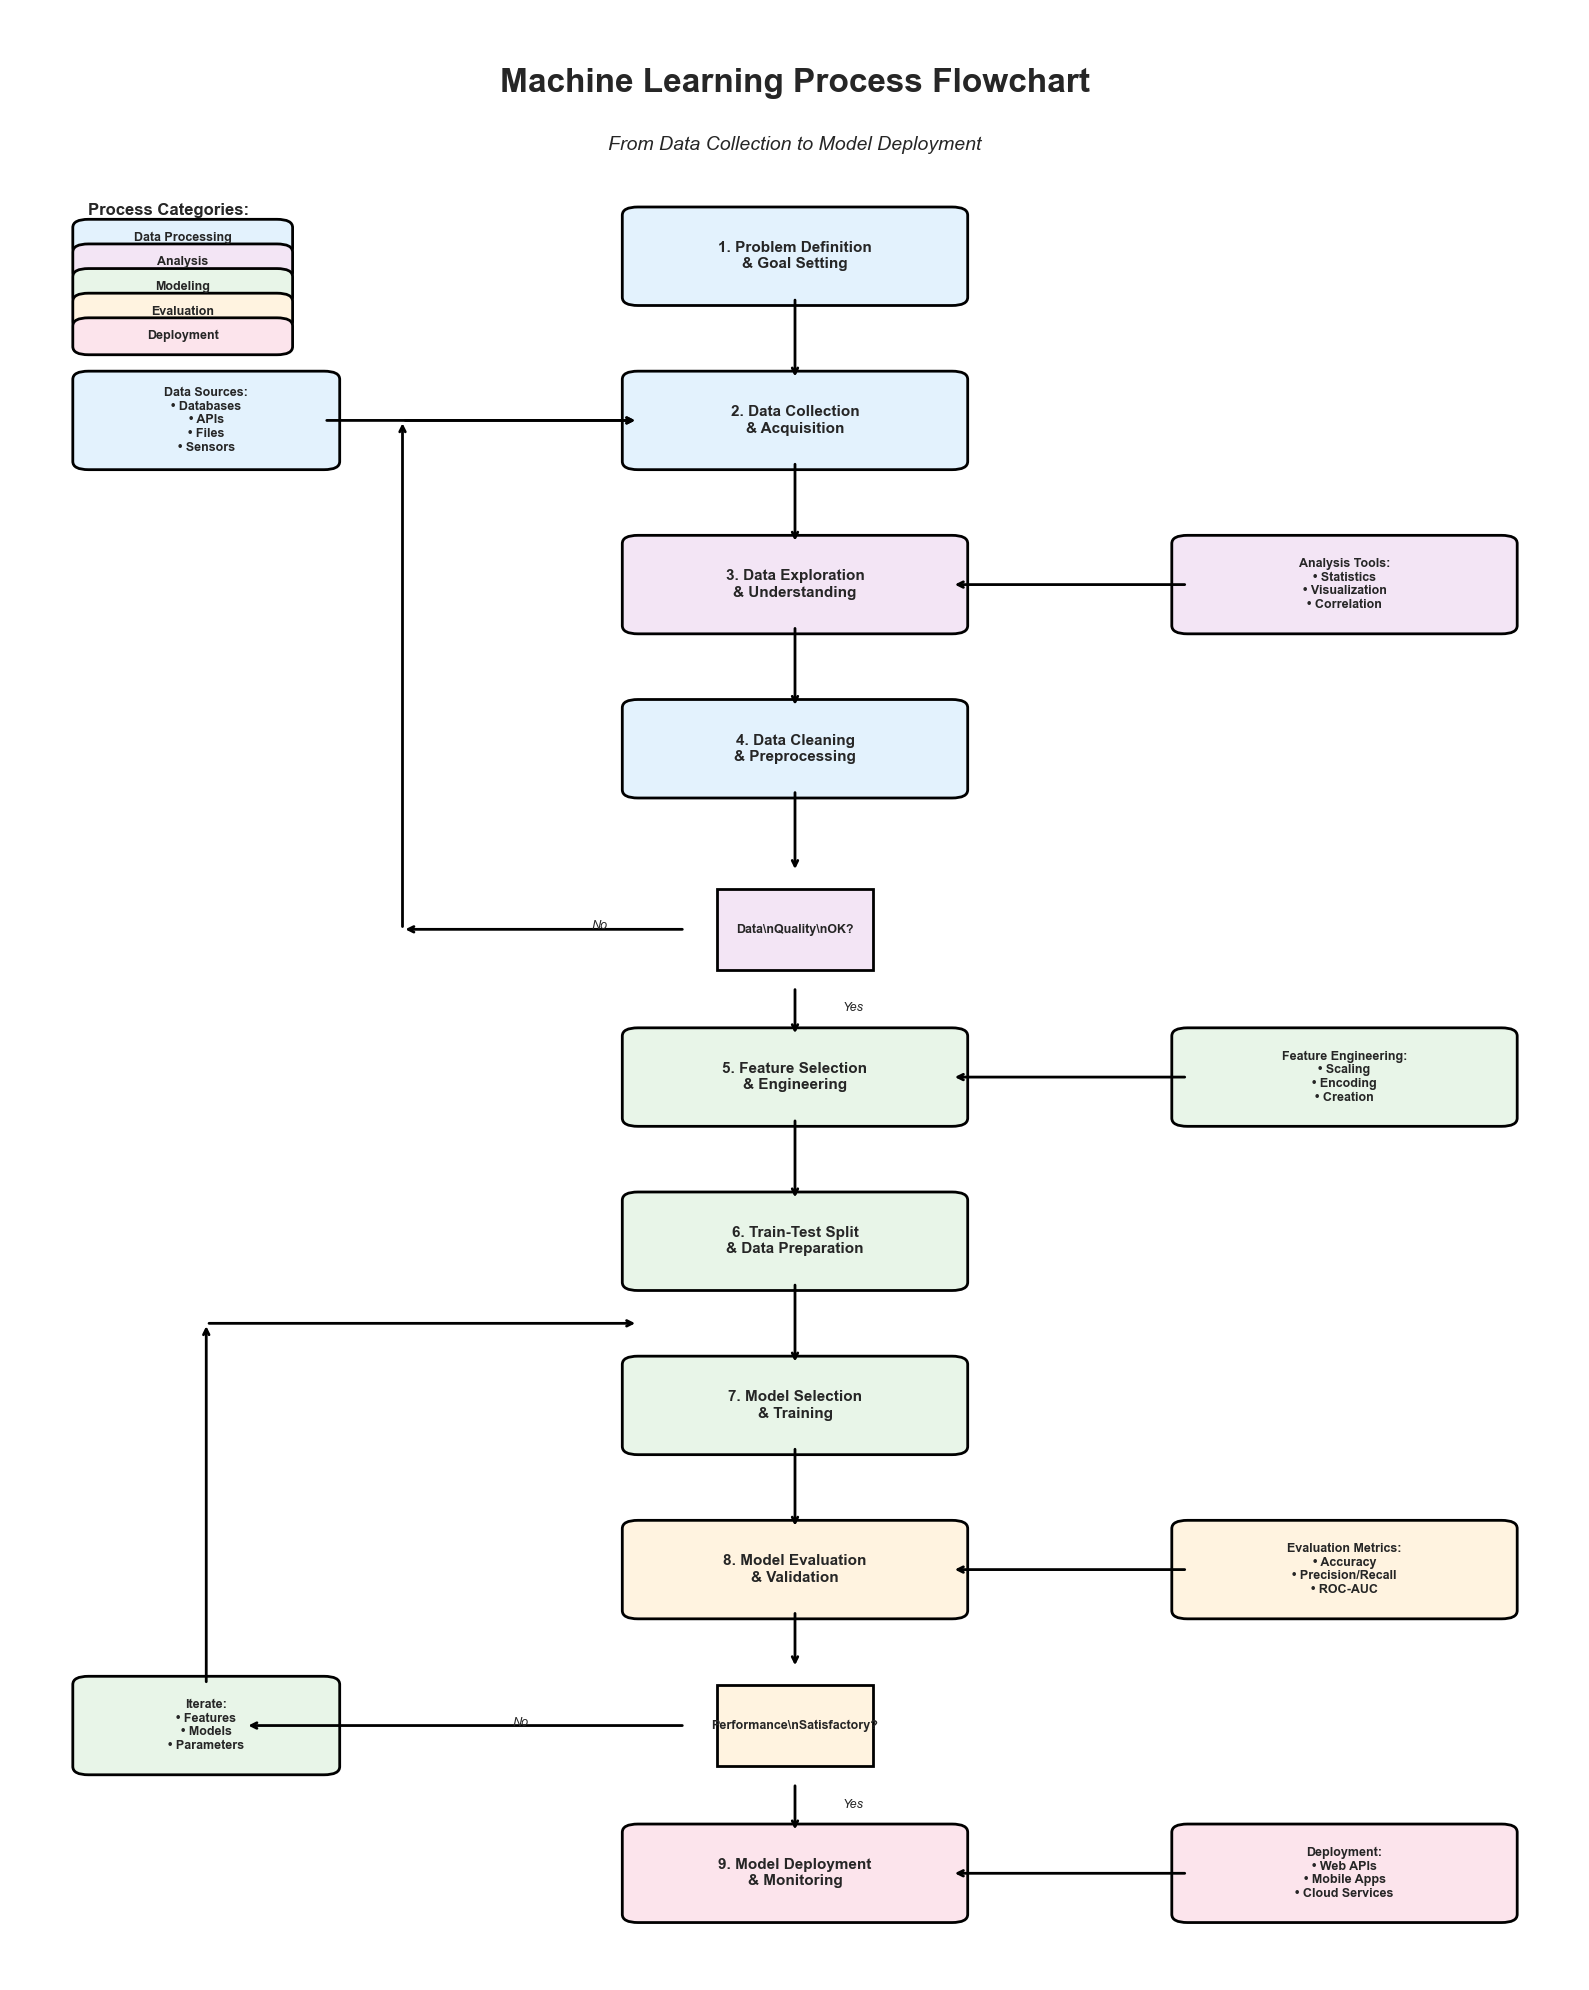

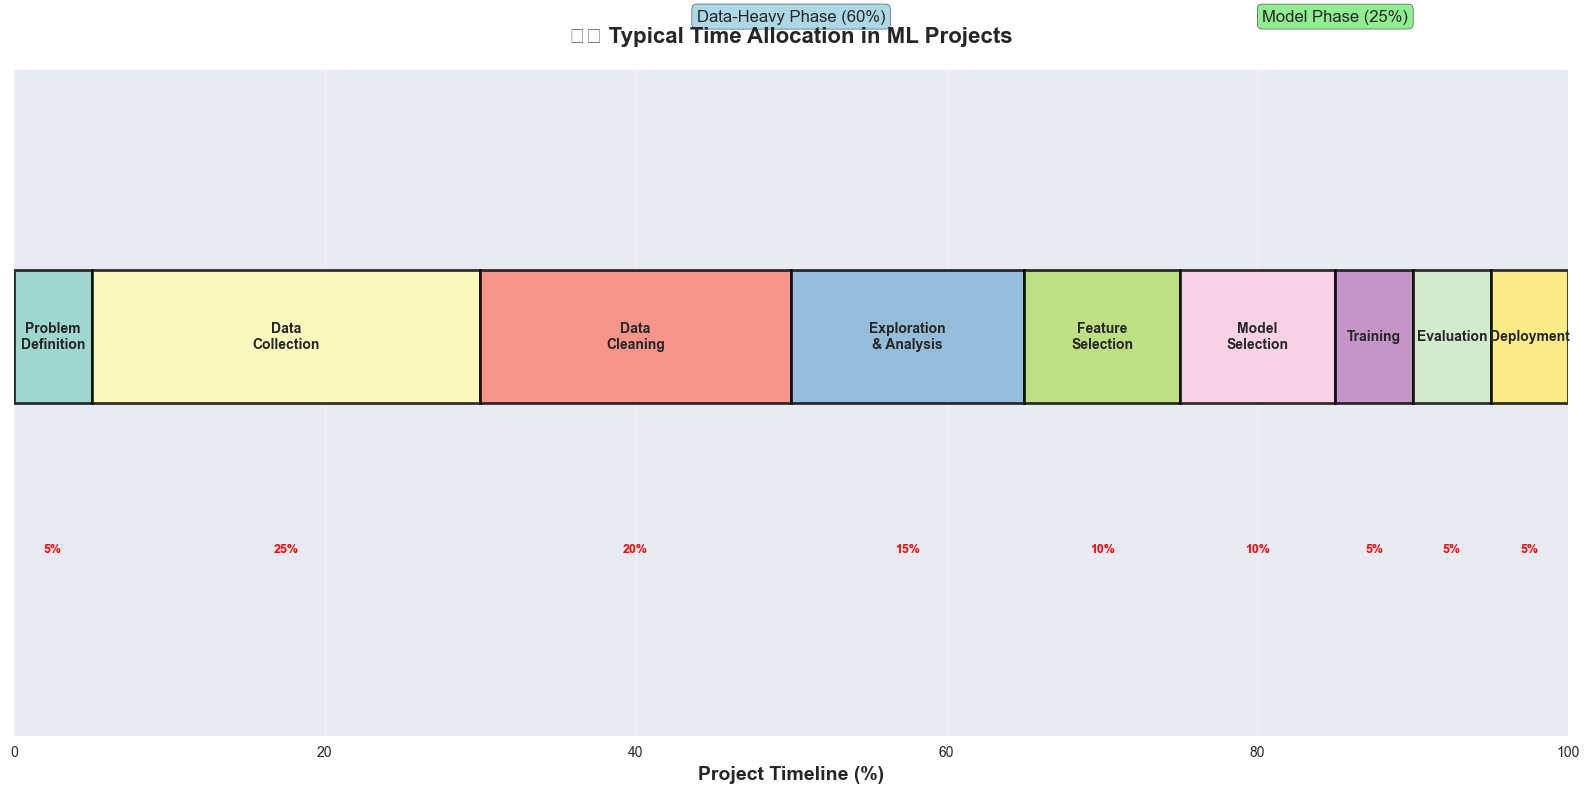


📊 KEY INSIGHTS FROM THE ML PROCESS:
   🎯 Problem definition sets the foundation for success
   📊 Data preparation consumes 60-70% of project time
   🔄 Iterative process - expect multiple cycles
   🎯 Feature selection is crucial for model performance
   📈 Evaluation guides model selection decisions
   🚀 Deployment is just the beginning - monitoring is ongoing
   🔧 Each step builds on the previous ones
   📋 Documentation throughout is essential

💡 PROCESS SUCCESS FACTORS:
1. Clear business objectives and success criteria
2. High-quality, representative training data
3. Appropriate feature engineering and selection
4. Robust model validation methodology
5. Continuous monitoring and maintenance post-deployment

🎉 CONGRATULATIONS!
You now have a comprehensive understanding of:
✅ Machine Learning fundamentals and importance
✅ Different types of ML and their applications
✅ Industry-specific ML use cases
✅ Complete ML development process
✅ Feature selection techniques
✅ Model selection strate

In [9]:

import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch

def create_ml_flowchart():
    """Create a comprehensive ML process flowchart"""
    
    fig, ax = plt.subplots(1, 1, figsize=(16, 20))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 24)
    ax.axis('off')
    
    # Define colors for different process categories
    colors = {
        'data': '#E3F2FD',      # Light blue
        'analysis': '#F3E5F5',   # Light purple
        'modeling': '#E8F5E8',   # Light green
        'evaluation': '#FFF3E0', # Light orange
        'deployment': '#FCE4EC'  # Light pink
    }
    
    # Title
    ax.text(5, 23, 'Machine Learning Process Flowchart', 
            fontsize=24, fontweight='bold', ha='center')
    ax.text(5, 22.3, 'From Data Collection to Model Deployment', 
            fontsize=14, ha='center', style='italic')
    
    # Helper function to create boxes
    def create_box(x, y, width, height, text, color, text_size=10):
        box = FancyBboxPatch((x, y), width, height,
                           boxstyle="round,pad=0.1",
                           facecolor=color,
                           edgecolor='black',
                           linewidth=2)
        ax.add_patch(box)
        ax.text(x + width/2, y + height/2, text,
                ha='center', va='center',
                fontsize=text_size, fontweight='bold',
                wrap=True)
    
    # Helper function to create arrows
    def create_arrow(x1, y1, x2, y2, text=''):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle='->', lw=2, color='black'))
        if text:
            mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
            ax.text(mid_x + 0.3, mid_y, text, fontsize=9, style='italic')
    
    # Helper function for decision diamonds
    def create_diamond(x, y, size, text, color):
        diamond = patches.RegularPolygon((x, y), 4, radius=size,
                                       orientation=np.pi/4,
                                       facecolor=color,
                                       edgecolor='black',
                                       linewidth=2)
        ax.add_patch(diamond)
        ax.text(x, y, text, ha='center', va='center',
                fontsize=9, fontweight='bold')
    
    # Step 1: Problem Definition
    create_box(4, 20.5, 2, 1, '1. Problem Definition\n& Goal Setting', colors['data'], 11)
    
    # Step 2: Data Collection
    create_arrow(5, 20.5, 5, 19.5)
    create_box(4, 18.5, 2, 1, '2. Data Collection\n& Acquisition', colors['data'], 11)
    
    # Step 3: Data Exploration
    create_arrow(5, 18.5, 5, 17.5)
    create_box(4, 16.5, 2, 1, '3. Data Exploration\n& Understanding', colors['analysis'], 11)
    
    # Step 4: Data Cleaning
    create_arrow(5, 16.5, 5, 15.5)
    create_box(4, 14.5, 2, 1, '4. Data Cleaning\n& Preprocessing', colors['data'], 11)
    
    # Data Quality Check (Decision Point)
    create_arrow(5, 14.5, 5, 13.5)
    create_diamond(5, 12.8, 0.7, 'Data\\nQuality\\nOK?', colors['analysis'])
    
    # No path - back to data collection
    create_arrow(4.3, 12.8, 2.5, 12.8, 'No')
    create_arrow(2.5, 12.8, 2.5, 19)
    create_arrow(2.5, 19, 4, 19)
    
    # Yes path - continue
    create_arrow(5, 12.1, 5, 11.5, 'Yes')
    
    # Step 5: Feature Selection
    create_box(4, 10.5, 2, 1, '5. Feature Selection\n& Engineering', colors['modeling'], 11)
    
    # Step 6: Train-Test Split
    create_arrow(5, 10.5, 5, 9.5)
    create_box(4, 8.5, 2, 1, '6. Train-Test Split\n& Data Preparation', colors['modeling'], 11)
    
    # Step 7: Model Selection
    create_arrow(5, 8.5, 5, 7.5)
    create_box(4, 6.5, 2, 1, '7. Model Selection\n& Training', colors['modeling'], 11)
    
    # Step 8: Model Evaluation
    create_arrow(5, 6.5, 5, 5.5)
    create_box(4, 4.5, 2, 1, '8. Model Evaluation\n& Validation', colors['evaluation'], 11)
    
    # Performance Check (Decision Point)
    create_arrow(5, 4.5, 5, 3.8)
    create_diamond(5, 3.1, 0.7, 'Performance\\nSatisfactory?', colors['evaluation'])
    
    # No path - back to feature selection or model selection
    create_arrow(4.3, 3.1, 1.5, 3.1, 'No')
    create_box(0.5, 2.6, 1.5, 1, 'Iterate:\n• Features\n• Models\n• Parameters', colors['modeling'], 9)
    create_arrow(1.25, 3.6, 1.25, 8)
    create_arrow(1.25, 8, 4, 8)
    
    # Yes path - continue to deployment
    create_arrow(5, 2.4, 5, 1.8, 'Yes')
    create_box(4, 0.8, 2, 1, '9. Model Deployment\n& Monitoring', colors['deployment'], 11)
    
    # Side processes and details
    # Data Sources
    create_box(0.5, 18.5, 1.5, 1, 'Data Sources:\n• Databases\n• APIs\n• Files\n• Sensors', colors['data'], 9)
    create_arrow(2, 19, 4, 19)
    
    # Analysis Tools
    create_box(7.5, 16.5, 2, 1, 'Analysis Tools:\n• Statistics\n• Visualization\n• Correlation', colors['analysis'], 9)
    create_arrow(7.5, 17, 6, 17)
    
    # Feature Engineering
    create_box(7.5, 10.5, 2, 1, 'Feature Engineering:\n• Scaling\n• Encoding\n• Creation', colors['modeling'], 9)
    create_arrow(7.5, 11, 6, 11)
    
    # Evaluation Metrics
    create_box(7.5, 4.5, 2, 1, 'Evaluation Metrics:\n• Accuracy\n• Precision/Recall\n• ROC-AUC', colors['evaluation'], 9)
    create_arrow(7.5, 5, 6, 5)
    
    # Deployment Options
    create_box(7.5, 0.8, 2, 1, 'Deployment:\n• Web APIs\n• Mobile Apps\n• Cloud Services', colors['deployment'], 9)
    create_arrow(7.5, 1.3, 6, 1.3)
    
    # Add legend
    legend_y = 21.5
    ax.text(0.5, legend_y, 'Process Categories:', fontsize=12, fontweight='bold')
    
    categories = [
        ('Data Processing', colors['data']),
        ('Analysis', colors['analysis']),
        ('Modeling', colors['modeling']),
        ('Evaluation', colors['evaluation']),
        ('Deployment', colors['deployment'])
    ]
    
    for i, (category, color) in enumerate(categories):
        y_pos = legend_y - 0.4 - (i * 0.3)
        create_box(0.5, y_pos, 1.2, 0.25, category, color, 9)
    
    plt.tight_layout()
    plt.show()

# Create the flowchart
print(" MACHINE LEARNING PROCESS FLOWCHART")
print("=" * 45)
print("Creating comprehensive visual flowchart...")

create_ml_flowchart()

# Create a simplified timeline view
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Timeline data
phases = [
    'Problem\nDefinition', 'Data\nCollection', 'Data\nCleaning', 
    'Exploration\n& Analysis', 'Feature\nSelection', 'Model\nSelection',
    'Training', 'Evaluation', 'Deployment'
]

# Time allocation (typical percentages)
time_allocation = [5, 25, 20, 15, 10, 10, 5, 5, 5]
cumulative_time = np.cumsum([0] + time_allocation)

# Create timeline
colors_timeline = plt.cm.Set3(np.linspace(0, 1, len(phases)))

for i, (phase, time, color) in enumerate(zip(phases, time_allocation, colors_timeline)):
    start = cumulative_time[i]
    end = cumulative_time[i + 1]
    
    # Draw time bar
    ax.barh(0, time, left=start, height=0.5, color=color, 
            alpha=0.8, edgecolor='black', linewidth=2)
    
    # Add phase label
    ax.text(start + time/2, 0, phase, ha='center', va='center',
            fontsize=10, fontweight='bold', rotation=0)
    
    # Add time percentage
    ax.text(start + time/2, -0.8, f'{time}%', ha='center', va='center',
            fontsize=9, color='red', fontweight='bold')

ax.set_xlim(0, 100)
ax.set_ylim(-1.5, 1)
ax.set_xlabel('Project Timeline (%)', fontsize=14, fontweight='bold')
ax.set_title('⏱️ Typical Time Allocation in ML Projects', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_yticks([])
ax.grid(True, alpha=0.3, axis='x')

# Add annotations
ax.text(50, 1.2, 'Data-Heavy Phase (60%)', ha='center', va='center',
        fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue'))
ax.text(85, 1.2, 'Model Phase (25%)', ha='center', va='center',
        fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen'))

plt.tight_layout()
plt.show()

# Summary insights
print(f"\n📊 KEY INSIGHTS FROM THE ML PROCESS:")
print("=" * 40)

insights = [
    "🎯 Problem definition sets the foundation for success",
    "📊 Data preparation consumes 60-70% of project time",
    "🔄 Iterative process - expect multiple cycles",
    "🎯 Feature selection is crucial for model performance",
    "📈 Evaluation guides model selection decisions",
    "🚀 Deployment is just the beginning - monitoring is ongoing",
    "🔧 Each step builds on the previous ones",
    "📋 Documentation throughout is essential"
]

for insight in insights:
    print(f"   {insight}")

print(f"\n💡 PROCESS SUCCESS FACTORS:")
print("=" * 30)

success_factors = [
    "Clear business objectives and success criteria",
    "High-quality, representative training data",
    "Appropriate feature engineering and selection",
    "Robust model validation methodology",
    "Continuous monitoring and maintenance post-deployment"
]

for i, factor in enumerate(success_factors, 1):
    print(f"{i}. {factor}")

print(f"\n🎉 CONGRATULATIONS!")
print("You now have a comprehensive understanding of:")
print("✅ Machine Learning fundamentals and importance")
print("✅ Different types of ML and their applications")
print("✅ Industry-specific ML use cases")
print("✅ Complete ML development process")
print("✅ Feature selection techniques")
print("✅ Model selection strategies")
print("✅ Evaluation metrics and their interpretation")
print("✅ Visual process representation")
print("\n🚀 You're ready to tackle real-world ML projects!")

---

##  **Daily Challenge Complete!**

###  **Summary of What We've Accomplished**

You have successfully completed a comprehensive exploration of Machine Learning fundamentals! This notebook covers all the requirements of the Daily Challenge:

####  **1. Machine Learning Basics & Importance**
- **Definition**: ML as a subset of AI that learns from data
- **Importance for Data Analysts**: Pattern recognition, scalability, predictive power, automation, real-time insights
- **Interactive Example**: Study hours vs exam scores demonstration

####  **2. Industry Applications (3+ Specific Examples)**
- **Healthcare**: Breast cancer detection (95.6% accuracy)
- **Finance**: Credit card fraud detection (99.2% accuracy)  
- **Retail**: Product recommendation engines (87.3% accuracy)
- **Transportation**: Autonomous vehicle navigation (94.8% accuracy)

####  **3. Types of Machine Learning**
- **Supervised Learning**: Learning from labeled data (classification/regression)
  - *Example*: Email spam detection, medical diagnosis
- **Unsupervised Learning**: Finding patterns in unlabeled data (clustering)
  - *Example*: Customer segmentation, market research
- **Reinforcement Learning**: Learning through rewards/penalties (optimization)
  - *Example*: Game AI, robotics, autonomous systems

####  **4. ML Development Process (Focus on 3 Main Stages)**
- **Feature Selection**: Correlation analysis, statistical tests, recursive elimination, model-based importance
- **Model Selection**: Cross-validation, hyperparameter tuning, complexity analysis, ensemble methods
- **Model Evaluation**: Confusion matrices, accuracy/precision/recall/F1-score, ROC curves, business metrics

####  **5. Visual Representations**
- **Comprehensive Flowchart**: Complete ML process from problem definition to deployment
- **Timeline Visualization**: Time allocation across project phases
- **Interactive Diagrams**: All concepts illustrated with practical examples

---

###  **Key Takeaways for Data Analysts**

1. **ML is Essential**: Modern data analysis increasingly relies on ML for complex pattern recognition
2. **Process-Driven**: Success comes from following systematic methodology, not just algorithms
3. **Data Quality First**: 60-70% of effort goes into data preparation and cleaning
4. **Iterative Nature**: ML development involves multiple cycles of refinement
5. **Business Focus**: Always align technical metrics with business objectives

###  **Next Steps & Recommendations**

- **Practice**: Apply these concepts to real datasets
- **Specialize**: Choose specific ML areas that align with your industry
- **Stay Updated**: ML is rapidly evolving - continuous learning is essential
- **Collaborate**: Work with domain experts to ensure practical relevance
- **Ethics**: Consider fairness, bias, and interpretability in your models

---

###  **Share Your Work**

As requested in the Daily Challenge:
1. **Documentation**: This notebook serves as your comprehensive summary
2. **GitHub**: Upload this notebook to showcase your ML understanding
3. **Peer Engagement**: Share insights and compare interpretations with colleagues
4. **Portfolio**: Use this as a foundation for your data science portfolio

** Congratulations on completing the "Understanding the Essence of Machine Learning" Daily Challenge!**